In [14]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import statsmodels.formula.api as smf
import statsmodels.api as sm

In [15]:
# Load the saved CSV file

fdv_df = pd.read_csv("fdv_and_mc_data_raw.csv")

# Optional: parse timestamps if needed
fdv_df['timestamp'] = pd.to_datetime(fdv_df['timestamp'])
fdv_df['token_name'].nunique()

5729

In [ ]:
# Create visualization function for dashboard
def create_dashboard(df, step_name, step_number):
    """Create the 4-panel dashboard for a given dataset"""
    # Copy the dataset and prepare for plotting
    plot_df = df.copy()
    plot_df = plot_df[(plot_df['FDV'] > 0) & (plot_df['MC'] > 0)]
    
    # Create figure layout
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    fig.suptitle(f'Step {step_number}: {step_name}\n'
                 f'Dataset: {plot_df.shape[0]} rows, {plot_df["symbol"].nunique()} unique tokens',
                 fontsize=16, fontweight='bold', y=0.995)
    
    # Panel A: FDV Distribution (log10)
    sns.histplot(np.log10(plot_df['FDV']), bins=100, ax=axes[0, 0], color='#1f77b4', alpha=0.7)
    axes[0, 0].set_title('Panel A: FDV Distribution (log₁₀ scale)', fontsize=13, loc='left', fontweight='bold')
    axes[0, 0].set_xlabel('log₁₀(FDV)', fontsize=12)
    axes[0, 0].set_ylabel('Count', fontsize=12)
    axes[0, 0].grid(True, alpha=0.3)
    axes[0, 0].set_facecolor('white')
    
    # Panel B: Market Cap Distribution (log10)
    sns.histplot(np.log10(plot_df['MC']), bins=100, ax=axes[0, 1], color='#ff7f0e', alpha=0.7)
    axes[0, 1].set_title('Panel B: Market Cap Distribution (log₁₀ scale)', fontsize=13, loc='left', fontweight='bold')
    axes[0, 1].set_xlabel('log₁₀(MC)', fontsize=12)
    axes[0, 1].set_ylabel('Count', fontsize=12)
    axes[0, 1].grid(True, alpha=0.3)
    axes[0, 1].set_facecolor('white')
    
    # Panel C: Circulating Supply Ratio (%CS)
    sns.histplot(plot_df['%CS'], bins=100, ax=axes[1, 0], color='#2ca02c', alpha=0.7)
    axes[1, 0].set_title('Panel C: Circulating Supply Ratio (%CS)', fontsize=13, loc='left', fontweight='bold')
    axes[1, 0].set_xlabel('Circulating Supply Ratio (%CS)', fontsize=12)
    axes[1, 0].set_ylabel('Count', fontsize=12)
    axes[1, 0].grid(True, alpha=0.3)
    axes[1, 0].set_facecolor('white')
    
    # Panel D: FDV vs Market Cap (log-log)
    sns.scatterplot(data=plot_df, x='FDV', y='MC', ax=axes[1, 1], color='#9467bd', alpha=0.4, edgecolor=None)
    axes[1, 1].set_xscale('log')
    axes[1, 1].set_yscale('log')
    axes[1, 1].set_title('Panel D: FDV vs Market Cap (log–log)', fontsize=13, loc='left', fontweight='bold')
    axes[1, 1].set_xlabel('Fully Diluted Valuation (FDV)', fontsize=12)
    axes[1, 1].set_ylabel('Market Capitalisation (MC)', fontsize=12)
    axes[1, 1].grid(True, alpha=0.3)
    axes[1, 1].set_facecolor('white')
    
    # Final layout and styling
    fig.patch.set_facecolor('white')
    plt.tight_layout(rect=[0, 0, 1, 0.97])
    plt.show()
    
    # Print summary statistics
    print(f"📊 Summary Statistics for {step_name}:")
    print(f"   FDV: mean={plot_df['FDV'].mean():.2e}, median={plot_df['FDV'].median():.2e}")
    print(f"   MC: mean={plot_df['MC'].mean():.2e}, median={plot_df['MC'].median():.2e}")
    print(f"   %CS: mean={plot_df['%CS'].mean():.3f}, median={plot_df['%CS'].median():.3f}")
    print(f"   %CS range: {plot_df['%CS'].min():.3f} - {plot_df['%CS'].max():.3f}")
    print()


In [17]:

# ---------- PARAMETERS ----------
start_date = "2022-06-01"
end_date = "2025-06-01"
min_weeks_per_token = 5
min_avg_mc = 5_000_000  # Minimum average market cap per token

# ---------- STEP 1: PREPARE DATA ----------
df = fdv_df.copy()

# Rename columns
df.rename(columns={
    'token_name': 'symbol',
    'fdv': 'FDV',
    'market_cap': 'MC'
}, inplace=True)

# Parse dates
df['timestamp'] = pd.to_datetime(df['timestamp'])

# Compute circulating supply ratio
df['%CS'] = df['MC'] / df['FDV']

# Drop invalid rows (FDV=0, NaNs, inf, etc.)
df = df.replace([np.inf, -np.inf], np.nan)
df = df[df['FDV'] > 0]
df = df[df['MC'] > 0]
df = df[df['%CS'].notna() & (df['%CS'] > 0) & (df['%CS'] <= 1)]
print(f"CHECK: Step 1: {df.shape[0]} rows, {df['symbol'].nunique()} unique tokens")

# ---------- STEP 2: FILTER BY DATE RANGE ----------
df = df[(df['timestamp'] >= start_date) & (df['timestamp'] <= end_date)].copy()
print(f"CHECK: Step 2: {df.shape[0]} rows, {df['symbol'].nunique()} unique tokens")

# ---------- STEP 3: REMOVE EXTREME OUTLIERS ----------
df = df[
    (df['FDV'] < df['FDV'].quantile(0.99)) &
    (df['MC'] < df['MC'].quantile(0.99))
].copy()
print(f"CHECK: Step 3: {df.shape[0]} rows, {df['symbol'].nunique()} unique tokens")

# ---------- STEP 4: REMOVE OBVIOUSLY BROKEN / UNREALISTIC DATA ----------
df = df[df['FDV'] < 1e12].copy()                               # FDV must be < $1T
df = df[df['FDV'] <= df['MC'] * 100]                   # FDV should not be 100x MC
df = df[~((df['FDV'] > 1e10) & (df['MC'] < 1e6))]    
print(f"CHECK: Step 4: {df.shape[0]} rows, {df['symbol'].nunique()} unique tokens")

# ---------- STEP 5: FILTER TOKENS WITH ENOUGH DATA ----------
token_counts = df['symbol'].value_counts()
valid_tokens = token_counts[token_counts >= min_weeks_per_token].index
df = df[df['symbol'].isin(valid_tokens)].copy()
print(f"CHECK: Step 5: {df.shape[0]} rows, {df['symbol'].nunique()} unique tokens")

# ---------- STEP 6: REMOVE CONSTANT OR BROKEN TOKENS ----------
fdv_std = df.groupby('symbol')['FDV'].std()
cs_std = df.groupby('symbol')['%CS'].std()
valid_tokens = fdv_std[(fdv_std > 0.0) & (cs_std > 0.0)].index
df = df[df['symbol'].isin(valid_tokens)].copy()
print(f"CHECK: Step 6: {df.shape[0]} rows, {df['symbol'].nunique()} unique tokens")

# ---------- STEP 6: REMOVE TOKENS WITH >95% CIRCULATING SUPPLY ----------
cs_max = df.groupby('symbol')['%CS'].max()
valid_tokens = cs_max[cs_max < 0.95].index
df = df[df['symbol'].isin(valid_tokens)].copy()
print(f"CHECK: Step 7: {df.shape[0]} rows, {df['symbol'].nunique()} unique tokens")

# ---------- STEP 7: REMOVE TOKENS WITH NEGATIVE %CS JUMPS (>10%) ----------
df_sorted = df.sort_values(['symbol', 'timestamp']).copy()
df_sorted['cs_diff'] = df_sorted.groupby('symbol')['%CS'].diff()
tokens_with_cs_drops = df_sorted[df_sorted['cs_diff'] < -0.10]['symbol'].unique()


df = df[~df['symbol'].isin(tokens_with_cs_drops)].copy()
print(f"CHECK: Step 8: {df.shape[0]} rows, {df['symbol'].nunique()} unique tokens")

# ---------- STEP 7: REMOVE VERY LOW CAP TOKENS ----------
avg_mc = df.groupby('symbol')['MC'].mean()
valid_tokens = avg_mc[avg_mc >= min_avg_mc].index
df = df[df['symbol'].isin(valid_tokens)].copy()
print(f"CHECK: Step 9: {df.shape[0]} rows, {df['symbol'].nunique()} unique tokens")

# ---------- STEP 8: KEEP ONLY TOP 1000 BY LATEST FDV ----------
latest_date = df['timestamp'].max()
top_500_tokens = (
    df[df['timestamp'] == latest_date]
    .groupby("symbol")["FDV"]
    .mean()
    .sort_values(ascending=False)
    .head(1000)
    .index
)
df = df[df['symbol'].isin(top_500_tokens)].copy()
print(f"CHECK: Step 10: {df.shape[0]} rows, {df['symbol'].nunique()} unique tokens")

# ---------- STEP 9: COMPUTE TGE DATE + DAYS FROM TGE ----------
df['TGE_date'] = df.groupby('symbol')['timestamp'].transform('min')
df['day_from_TGE'] = (df['timestamp'] - df['TGE_date']).dt.days
df.drop(columns=['TGE_date'], inplace=True)

#print(f"CEHCK: Step 9: {df.shape[0]} rows, {df['symbol'].nunique()} unique tokens")
# ---------- STEP 10: CLEANUP ----------
df = df.drop_duplicates(subset=['timestamp', 'symbol']).sort_values(['symbol', 'timestamp'])
df = df.reset_index(drop=True)
df = df[['timestamp', 'symbol', 'day_from_TGE', '%CS', 'MC', 'FDV']]

print(f"✅ Final dataset: {df.shape[0]} rows, {df['symbol'].nunique()} unique tokens")


CHECK: Step 1: 261567 rows, 3962 unique tokens
CHECK: Step 2: 229626 rows, 3816 unique tokens
CHECK: Step 3: 225708 rows, 3786 unique tokens
CHECK: Step 4: 221629 rows, 3744 unique tokens
CHECK: Step 5: 221108 rows, 3500 unique tokens
CHECK: Step 6: 178438 rows, 2812 unique tokens
CHECK: Step 7: 138377 rows, 1867 unique tokens
CHECK: Step 8: 114003 rows, 1598 unique tokens
CHECK: Step 9: 68770 rows, 874 unique tokens
CHECK: Step 10: 66253 rows, 826 unique tokens
✅ Final dataset: 66253 rows, 826 unique tokens


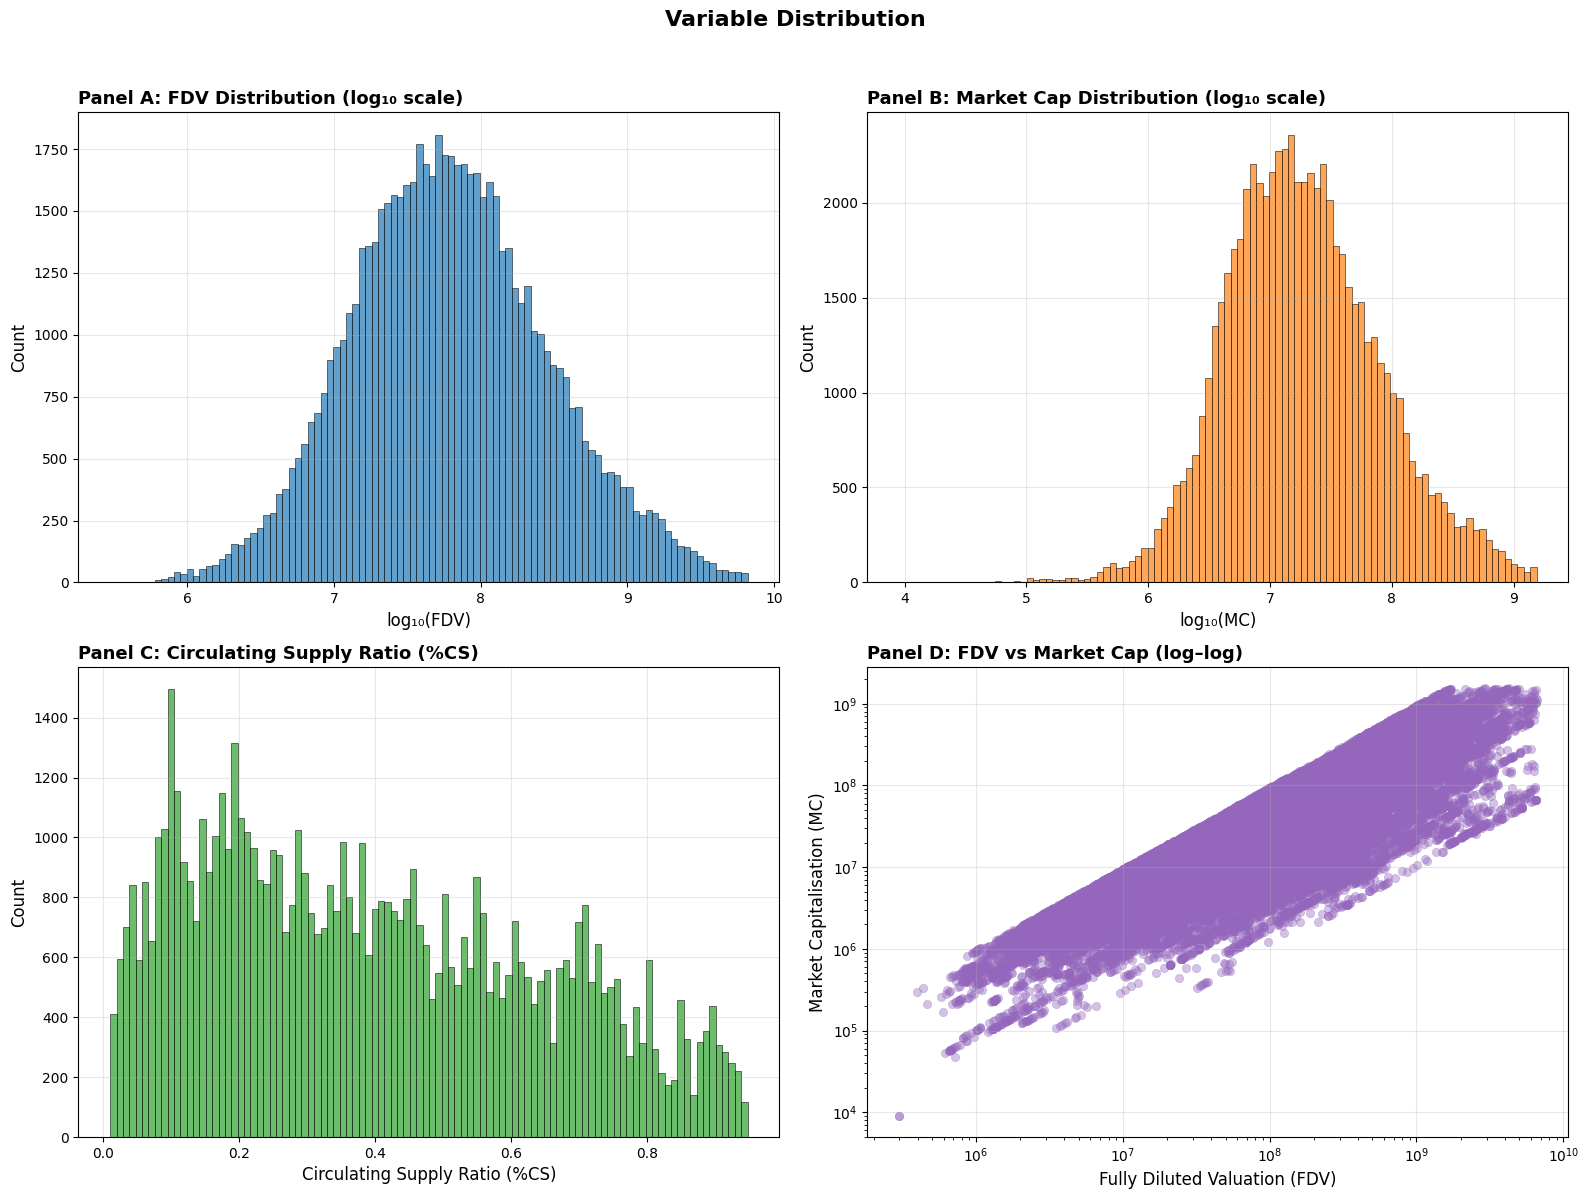

In [18]:

# Copy the cleaned dataset
plot_df = df.copy()

# Replace zeros to avoid issues with log scale
plot_df = plot_df[(plot_df['FDV'] > 0) & (plot_df['MC'] > 0)]

# Sample top 6 tokens with most data points
top_tokens = plot_df['symbol'].value_counts().head(6).index
sample_df = plot_df[plot_df['symbol'].isin(top_tokens)].copy()

# ------------------------------------------------------
# Cleaned Token Data — Post-Processing Dashboard (Log Scales)
# ------------------------------------------------------
plt.style.use('default')
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Variable Distribution',
             fontsize=16, fontweight='bold', y=0.995)

# Panel A: FDV Distribution (log10)
sns.histplot(np.log10(plot_df['FDV']), bins=100, ax=axes[0, 0], color='#1f77b4', alpha=0.7)
axes[0, 0].set_title('Panel A: FDV Distribution (log₁₀ scale)', fontsize=13, loc='left', fontweight='bold')
axes[0, 0].set_xlabel('log₁₀(FDV)', fontsize=12)
axes[0, 0].set_ylabel('Count', fontsize=12)
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].set_facecolor('white')

# Panel B: Market Cap Distribution (log10)
sns.histplot(np.log10(plot_df['MC']), bins=100, ax=axes[0, 1], color='#ff7f0e', alpha=0.7)
axes[0, 1].set_title('Panel B: Market Cap Distribution (log₁₀ scale)', fontsize=13, loc='left', fontweight='bold')
axes[0, 1].set_xlabel('log₁₀(MC)', fontsize=12)
axes[0, 1].set_ylabel('Count', fontsize=12)
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].set_facecolor('white')

# Panel C: Circulating Supply Ratio (%CS)
sns.histplot(plot_df['%CS'], bins=100, ax=axes[1, 0], color='#2ca02c', alpha=0.7)
axes[1, 0].set_title('Panel C: Circulating Supply Ratio (%CS)', fontsize=13, loc='left', fontweight='bold')
axes[1, 0].set_xlabel('Circulating Supply Ratio (%CS)', fontsize=12)
axes[1, 0].set_ylabel('Count', fontsize=12)
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].set_facecolor('white')

# Panel D: FDV vs Market Cap (log-log)
sns.scatterplot(data=plot_df, x='FDV', y='MC', ax=axes[1, 1], color='#9467bd', alpha=0.4, edgecolor=None)
axes[1, 1].set_xscale('log')
axes[1, 1].set_yscale('log')
axes[1, 1].set_title('Panel D: FDV vs Market Cap (log–log)', fontsize=13, loc='left', fontweight='bold')
axes[1, 1].set_xlabel('Fully Diluted Valuation (FDV)', fontsize=12)
axes[1, 1].set_ylabel('Market Capitalisation (MC)', fontsize=12)
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].set_facecolor('white')

# Final layout and styling
fig.patch.set_facecolor('white')
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()


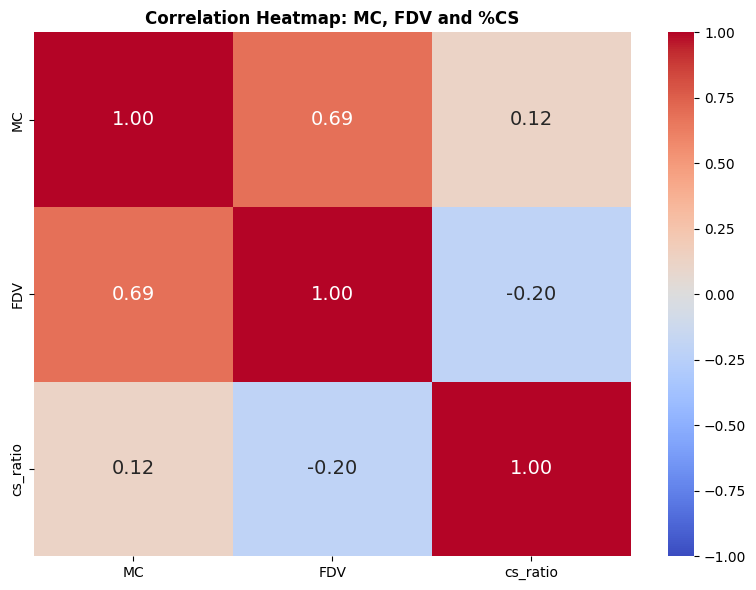

In [19]:

df['cs_ratio'] = df['MC'] / df['FDV']
# Select relevant columns
corr_data = df[[ 'MC', 'FDV','cs_ratio']]

# Compute correlation matrix
corr_matrix = corr_data.corr(method='pearson')

# Plot heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1, annot_kws={"size": 14})
plt.title("Correlation Heatmap: MC, FDV and %CS", fontweight='bold')
plt.tight_layout()
plt.show()

In [20]:


# Rename %CS to a safe variable name for formula parsing
#df = df.rename(columns={'%CS': 'cs_ratio'})

# Add log variables (if not already done)
df['log_FDV'] = np.log(df['FDV'])
df['log_MC'] = np.log(df['MC'])

# Define models
models = {
    'MC ~ cs_ratio': 'MC ~ cs_ratio',
    'FDV ~ cs_ratio': 'FDV ~ cs_ratio',
    'log_MC ~ cs_ratio': 'log_MC ~ cs_ratio',
    'log_FDV ~ cs_ratio': 'log_FDV ~ cs_ratio'
}

print("📊 Cluster-Robust Regressions (p-values & R²):\n")

for name, formula in models.items():
    model = smf.ols(formula, data=df)
    result = model.fit(cov_type='cluster', cov_kwds={'groups': df['symbol']})

    pval = result.pvalues['cs_ratio']
    r2 = result.rsquared

    print(f"{name}: p = {pval:.4g}, R² = {r2:.3f}")

📊 Cluster-Robust Regressions (p-values & R²):

MC ~ cs_ratio: p = 0.0006725, R² = 0.015
FDV ~ cs_ratio: p = 7.941e-14, R² = 0.041
log_MC ~ cs_ratio: p = 2.565e-08, R² = 0.030
log_FDV ~ cs_ratio: p = 3.102e-27, R² = 0.113


In [21]:
# Define your X and Y
X = sm.add_constant(df['cs_ratio'])  
cluster_var = df['symbol']           # clustering variable

# -------- log(MC) ~ %CS --------
model_mc_inital = sm.OLS(df['log_MC'], X).fit(cov_type='cluster', cov_kwds={'groups': cluster_var})
print("🔹 Regression: log(MC) ~ %CS (Cluster-Robust)")
print(model_mc_inital.summary())

# -------- log(FDV) ~ %CS --------
model_fdv_inital = sm.OLS(df['log_FDV'], X).fit(cov_type='cluster', cov_kwds={'groups': cluster_var})
print("\n🔹 Regression: log(FDV) ~ %CS (Cluster-Robust)")
print(model_fdv_inital.summary())

🔹 Regression: log(MC) ~ %CS (Cluster-Robust)
                            OLS Regression Results                            
Dep. Variable:                 log_MC   R-squared:                       0.030
Model:                            OLS   Adj. R-squared:                  0.030
Method:                 Least Squares   F-statistic:                     31.01
Date:                Sat, 18 Oct 2025   Prob (F-statistic):           3.47e-08
Time:                        23:18:28   Log-Likelihood:            -1.1782e+05
No. Observations:               66253   AIC:                         2.356e+05
Df Residuals:                   66251   BIC:                         2.357e+05
Df Model:                           1                                         
Covariance Type:              cluster                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const  

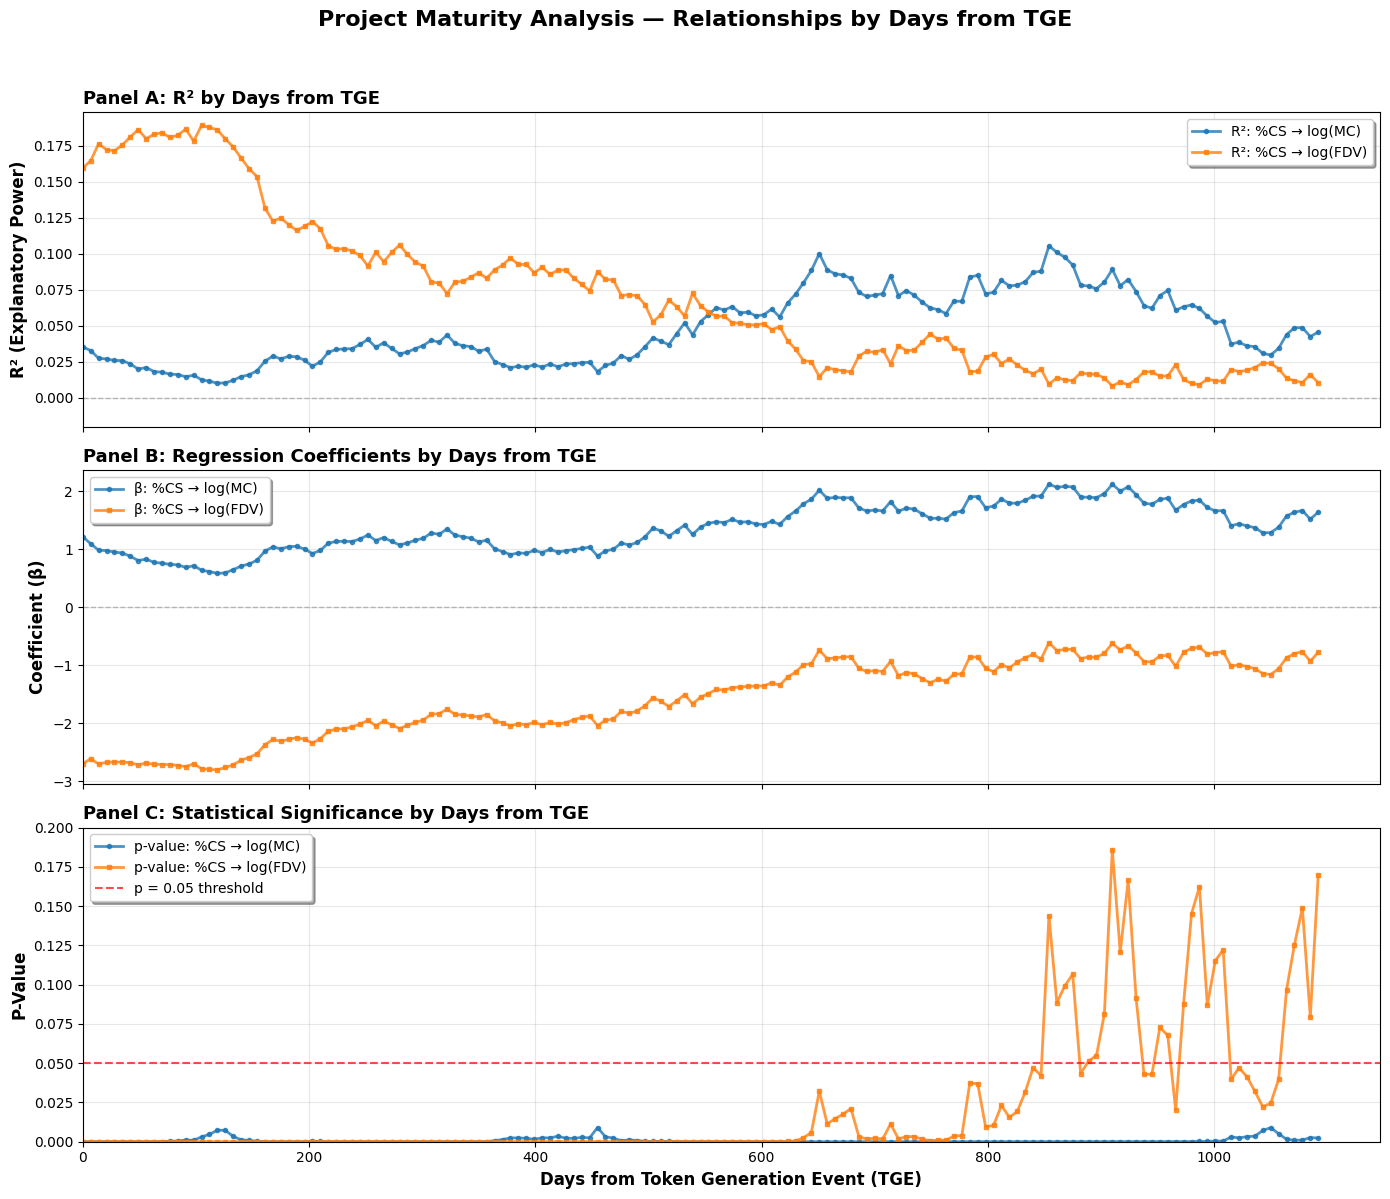

In [ ]:
# ------------------------------------------------------
# 1. Run cluster-robust regressions by day_from_TGE
# ------------------------------------------------------
regression_stats = []

for day, group in df.groupby('day_from_TGE'):
    n_obs = len(group)
    n_projects = group['symbol'].nunique()
    if n_projects >= 5:
        try:
            mc_model = smf.ols('log_MC ~ cs_ratio', data=group).fit(
                cov_type='cluster', cov_kwds={'groups': group['symbol']}
            )
            fdv_model = smf.ols('log_FDV ~ cs_ratio', data=group).fit(
                cov_type='cluster', cov_kwds={'groups': group['symbol']}
            )

            regression_stats.append({
                'day_from_TGE': day,
                'n_obs': n_obs,
                'n_projects': n_projects,
                'r2_MC': mc_model.rsquared,
                'r2_FDV': fdv_model.rsquared,
                'coef_MC': mc_model.params['cs_ratio'],
                'coef_FDV': fdv_model.params['cs_ratio'],
                'pval_MC': mc_model.pvalues['cs_ratio'],
                'pval_FDV': fdv_model.pvalues['cs_ratio']
            })
        except:
            continue

# Create DataFrame
maturity_df = pd.DataFrame(regression_stats).sort_values('day_from_TGE')

# ------------------------------------------------------
# 2. Combined three-panel chart
# ------------------------------------------------------
plt.style.use('default')
fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True)
fig.suptitle('Project Maturity Analysis — Relationships by Days from TGE',
             fontsize=16, fontweight='bold', y=0.995)

# Chart 4: R² by days
axes[0].plot(maturity_df['day_from_TGE'], maturity_df['r2_MC'],
             marker='o', markersize=3, linewidth=2, label='R²: %CS → log(MC)', color='#1f77b4', alpha=0.8)
axes[0].plot(maturity_df['day_from_TGE'], maturity_df['r2_FDV'],
             marker='s', markersize=3, linewidth=2, label='R²: %CS → log(FDV)', color='#ff7f0e', alpha=0.8)
axes[0].axhline(0, color='gray', linestyle='--', linewidth=1, alpha=0.5)
axes[0].set_ylabel('R² (Explanatory Power)', fontsize=12, fontweight='bold')
axes[0].set_title('Panel A: R² by Days from TGE', fontsize=13, loc='left', fontweight='bold')
axes[0].legend(loc='best', frameon=True, shadow=True)
axes[0].grid(True, alpha=0.3)
axes[0].set_xlim(left=0)
axes[0].set_ylim(bottom=-0.02)

# Chart 5: Coefficients
axes[1].plot(maturity_df['day_from_TGE'], maturity_df['coef_MC'],
             marker='o', markersize=3, linewidth=2, label='β: %CS → log(MC)', color='#1f77b4', alpha=0.8)
axes[1].plot(maturity_df['day_from_TGE'], maturity_df['coef_FDV'],
             marker='s', markersize=3, linewidth=2, label='β: %CS → log(FDV)', color='#ff7f0e', alpha=0.8)
axes[1].axhline(0, color='gray', linestyle='--', linewidth=1, alpha=0.5)
axes[1].set_ylabel('Coefficient (β)', fontsize=12, fontweight='bold')
axes[1].set_title('Panel B: Regression Coefficients by Days from TGE', fontsize=13, loc='left', fontweight='bold')
axes[1].legend(loc='best', frameon=True, shadow=True)
axes[1].grid(True, alpha=0.3)
axes[1].set_xlim(left=0)

# Chart 6: P-values
axes[2].plot(maturity_df['day_from_TGE'], maturity_df['pval_MC'],
             marker='o', markersize=3, linewidth=2, label='p-value: %CS → log(MC)', color='#1f77b4', alpha=0.8)
axes[2].plot(maturity_df['day_from_TGE'], maturity_df['pval_FDV'],
             marker='s', markersize=3, linewidth=2, label='p-value: %CS → log(FDV)', color='#ff7f0e', alpha=0.8)
axes[2].axhline(0.05, color='red', linestyle='--', linewidth=1.5, alpha=0.7, label='p = 0.05 threshold')
axes[2].set_ylabel('P-Value', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Days from Token Generation Event (TGE)', fontsize=12, fontweight='bold')
axes[2].set_title('Panel C: Statistical Significance by Days from TGE', fontsize=13, loc='left', fontweight='bold')
axes[2].legend(loc='best', frameon=True, shadow=True)
axes[2].grid(True, alpha=0.3)
axes[2].set_xlim(left=0)
axes[2].set_ylim([0, 0.2])

# White background
fig.patch.set_facecolor('white')
for ax in axes:
    ax.set_facecolor('white')

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

In [23]:


csv_path = "bitcoin_market_data.csv"

bitcoin_df = pd.read_csv(csv_path, parse_dates=['timestamp'])
print("Loaded data from CSV:")
print(bitcoin_df.head())


Loaded data from CSV:
   timestamp  bitcoin_price
0 2013-04-28         117.00
1 2013-05-05         113.01
2 2013-05-12         115.50
3 2013-05-19         123.00
4 2013-05-26         129.09


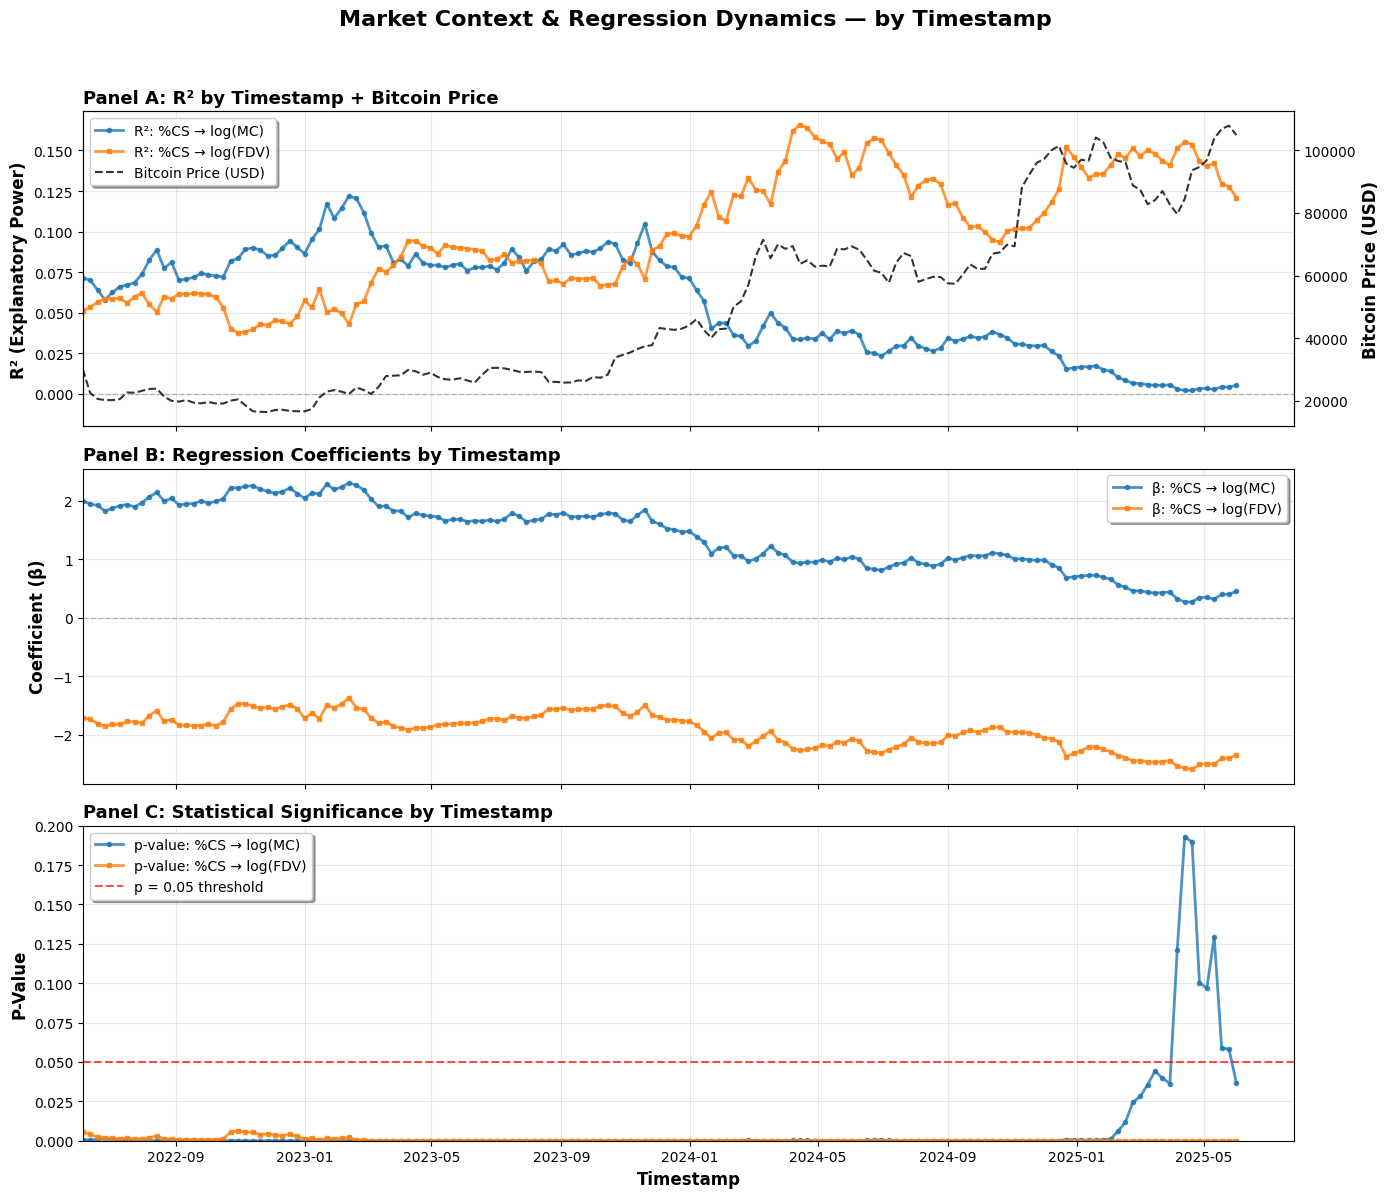

In [24]:
# ------------------------------------------------------
# 1. Run cluster-robust regressions by timestamp
# ------------------------------------------------------
results = []
for ts, group in df.groupby('timestamp'):
    if group['symbol'].nunique() >= 5:
        try:
            mc_model = smf.ols('log_MC ~ cs_ratio', data=group).fit(
                cov_type='cluster', cov_kwds={'groups': group['symbol']}
            )
            fdv_model = smf.ols('log_FDV ~ cs_ratio', data=group).fit(
                cov_type='cluster', cov_kwds={'groups': group['symbol']}
            )

            results.append({
                'timestamp': ts,
                'n_obs': len(group),
                'r2_MC': mc_model.rsquared,
                'r2_FDV': fdv_model.rsquared,
                'coef_MC': mc_model.params['cs_ratio'],
                'coef_FDV': fdv_model.params['cs_ratio'],
                'pval_MC': mc_model.pvalues['cs_ratio'],
                'pval_FDV': fdv_model.pvalues['cs_ratio']
            })
        except:
            continue

robust_df = pd.DataFrame(results).sort_values('timestamp')

# ------------------------------------------------------
# 2. Load Bitcoin market data
# ------------------------------------------------------
bitcoin_df = pd.read_csv("bitcoin_market_data.csv", parse_dates=['timestamp'])
bitcoin_df['timestamp'] = pd.to_datetime(bitcoin_df['timestamp']).dt.tz_localize(None)
robust_df['timestamp'] = pd.to_datetime(robust_df['timestamp']).dt.tz_localize(None)

# Merge on timestamp
merged_df = pd.merge(robust_df, bitcoin_df, on='timestamp', how='left')

# ------------------------------------------------------
# 3. Combined three-panel layout
# ------------------------------------------------------
plt.style.use('default')
fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True)
fig.suptitle('Market Context & Regression Dynamics — by Timestamp',
             fontsize=16, fontweight='bold', y=0.995)

# ------------------------
# Chart 4: R² + BTC price
# ------------------------
ax1 = axes[0]
ax1.plot(merged_df['timestamp'], merged_df['r2_MC'],
         marker='o', markersize=3, linewidth=2, label='R²: %CS → log(MC)', color='#1f77b4', alpha=0.8)
ax1.plot(merged_df['timestamp'], merged_df['r2_FDV'],
         marker='s', markersize=3, linewidth=2, label='R²: %CS → log(FDV)', color='#ff7f0e', alpha=0.8)
ax1.axhline(0, color='gray', linestyle='--', linewidth=1, alpha=0.5)
ax1.set_ylabel('R² (Explanatory Power)', fontsize=12, fontweight='bold')
ax1.set_title('Panel A: R² by Timestamp + Bitcoin Price', fontsize=13, loc='left', fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.set_xlim(left=merged_df['timestamp'].min())
ax1.set_ylim(bottom=-0.02)

# Right axis: Bitcoin price
ax2 = ax1.twinx()
ax2.plot(merged_df['timestamp'], merged_df['bitcoin_price'],
         color='black', linestyle='--', linewidth=1.5, label='Bitcoin Price (USD)', alpha=0.8)
ax2.set_ylabel('Bitcoin Price (USD)', fontsize=12, fontweight='bold')

# Combine legends
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper left', frameon=True, shadow=True, fontsize=10)

# ------------------------
# Chart 5: Coefficients
# ------------------------
axes[1].plot(merged_df['timestamp'], merged_df['coef_MC'],
             marker='o', markersize=3, linewidth=2, label='β: %CS → log(MC)', color='#1f77b4', alpha=0.8)
axes[1].plot(merged_df['timestamp'], merged_df['coef_FDV'],
             marker='s', markersize=3, linewidth=2, label='β: %CS → log(FDV)', color='#ff7f0e', alpha=0.8)
axes[1].axhline(0, color='gray', linestyle='--', linewidth=1, alpha=0.5)
axes[1].set_ylabel('Coefficient (β)', fontsize=12, fontweight='bold')
axes[1].set_title('Panel B: Regression Coefficients by Timestamp', fontsize=13, loc='left', fontweight='bold')
axes[1].legend(loc='best', frameon=True, shadow=True)
axes[1].grid(True, alpha=0.3)
axes[1].set_xlim(left=merged_df['timestamp'].min())

# ------------------------
# Chart 6: P-values
# ------------------------
axes[2].plot(merged_df['timestamp'], merged_df['pval_MC'],
             marker='o', markersize=3, linewidth=2, label='p-value: %CS → log(MC)', color='#1f77b4', alpha=0.8)
axes[2].plot(merged_df['timestamp'], merged_df['pval_FDV'],
             marker='s', markersize=3, linewidth=2, label='p-value: %CS → log(FDV)', color='#ff7f0e', alpha=0.8)
axes[2].axhline(0.05, color='red', linestyle='--', linewidth=1.5, alpha=0.7, label='p = 0.05 threshold')
axes[2].set_ylabel('P-Value', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Timestamp', fontsize=12, fontweight='bold')
axes[2].set_title('Panel C: Statistical Significance by Timestamp', fontsize=13, loc='left', fontweight='bold')
axes[2].legend(loc='best', frameon=True, shadow=True)
axes[2].grid(True, alpha=0.3)
axes[2].set_xlim(left=merged_df['timestamp'].min())
axes[2].set_ylim([0, 0.2])

# White background
fig.patch.set_facecolor('white')
for ax in axes:
    ax.set_facecolor('white')
    for label in ax.get_xticklabels() + ax.get_yticklabels():
        label.set_fontweight('normal')  # make tick labels non-bold

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()


🔍 VISUALIZING DATA AT EACH FILTERING STEP
CEHCK: Step 1: 261567 rows, 3962 unique tokens


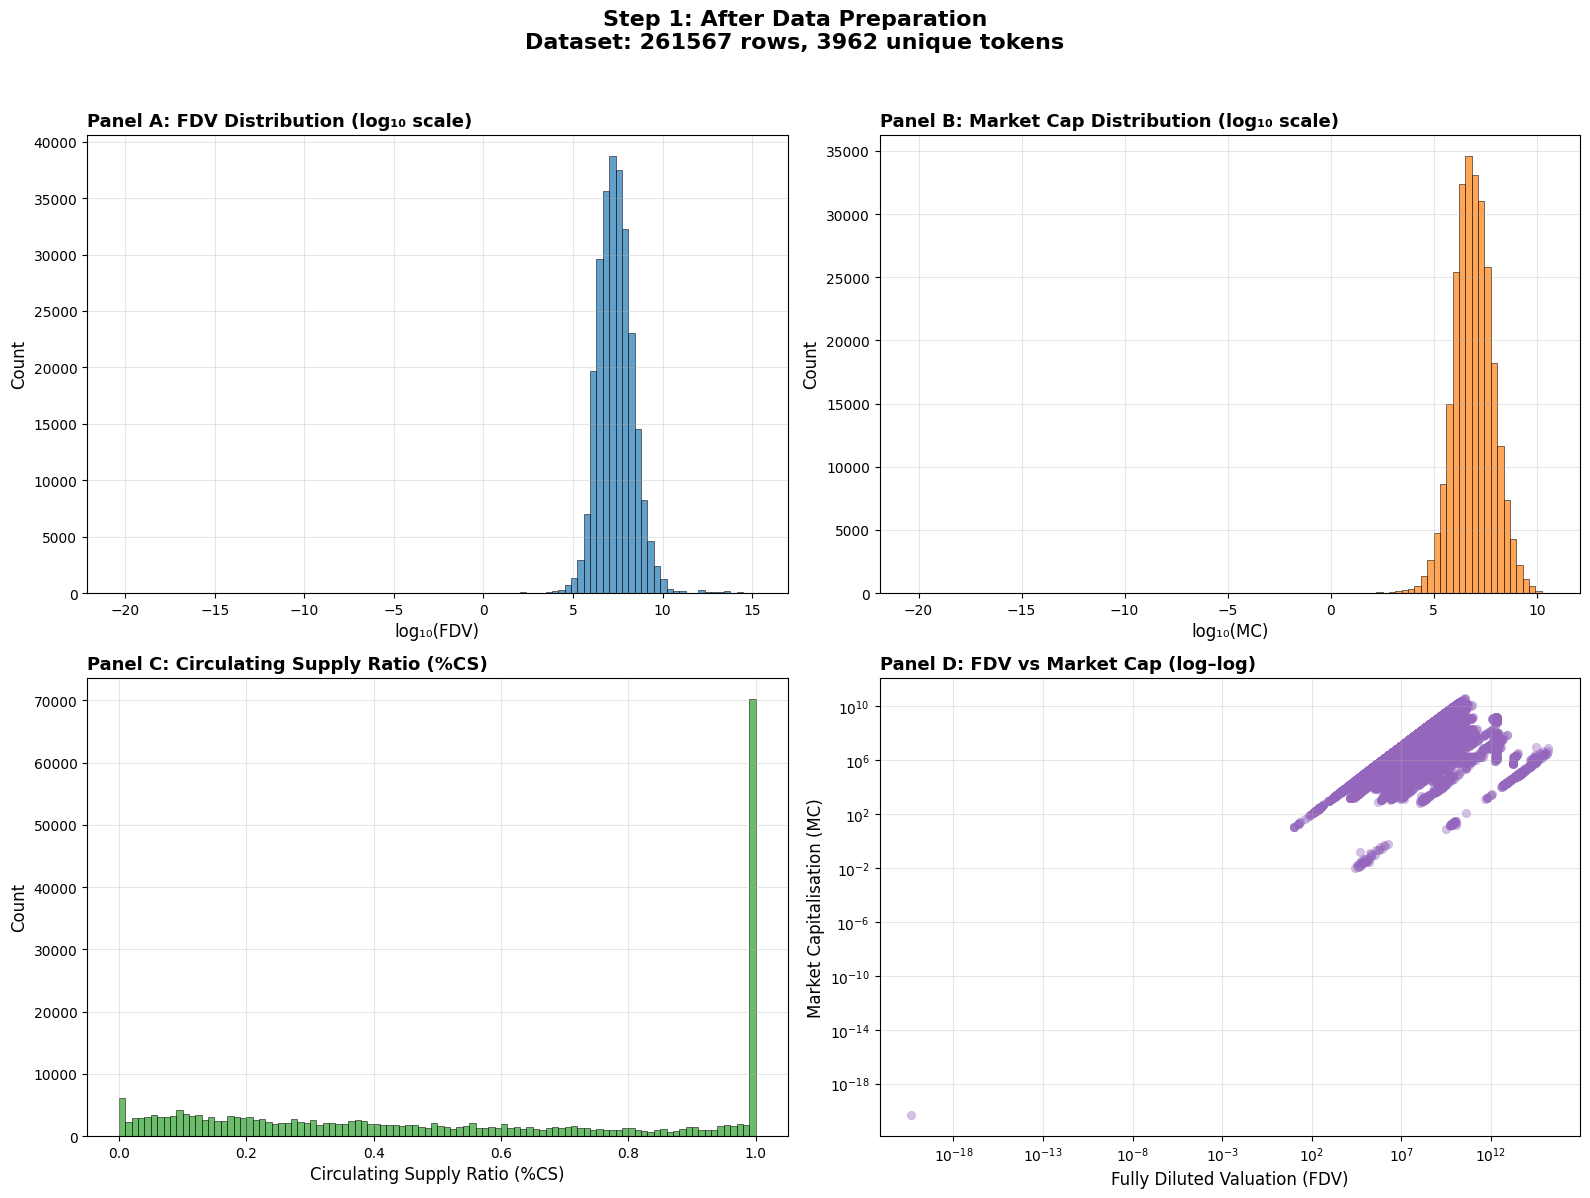

📊 Summary Statistics for After Data Preparation:
   FDV: mean=1.57e+11, median=2.13e+07
   MC: mean=9.16e+07, median=7.71e+06
   %CS: mean=0.554, median=0.522
   %CS range: 0.000 - 1.000

CEHCK: Step 2: 229626 rows, 3816 unique tokens


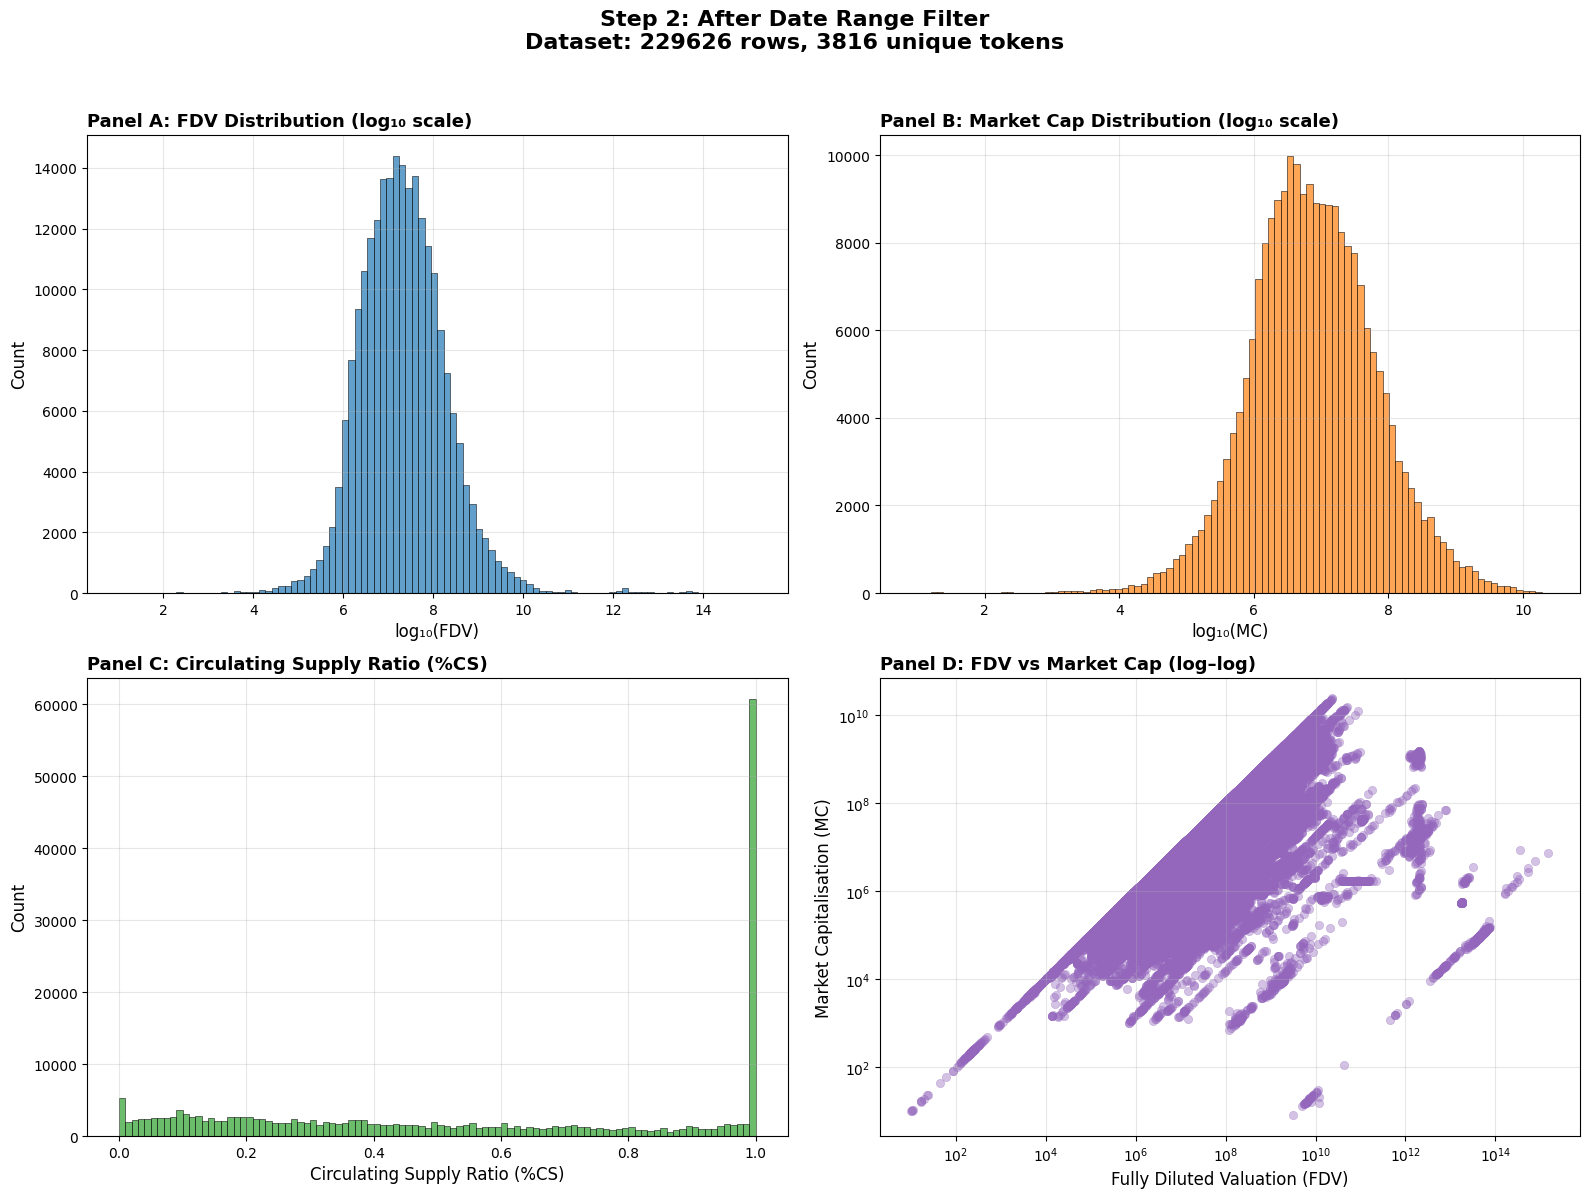

📊 Summary Statistics for After Date Range Filter:
   FDV: mean=6.65e+10, median=1.94e+07
   MC: mean=8.67e+07, median=7.11e+06
   %CS: mean=0.560, median=0.536
   %CS range: 0.000 - 1.000

CEHCK: Step 3: 225708 rows, 3786 unique tokens


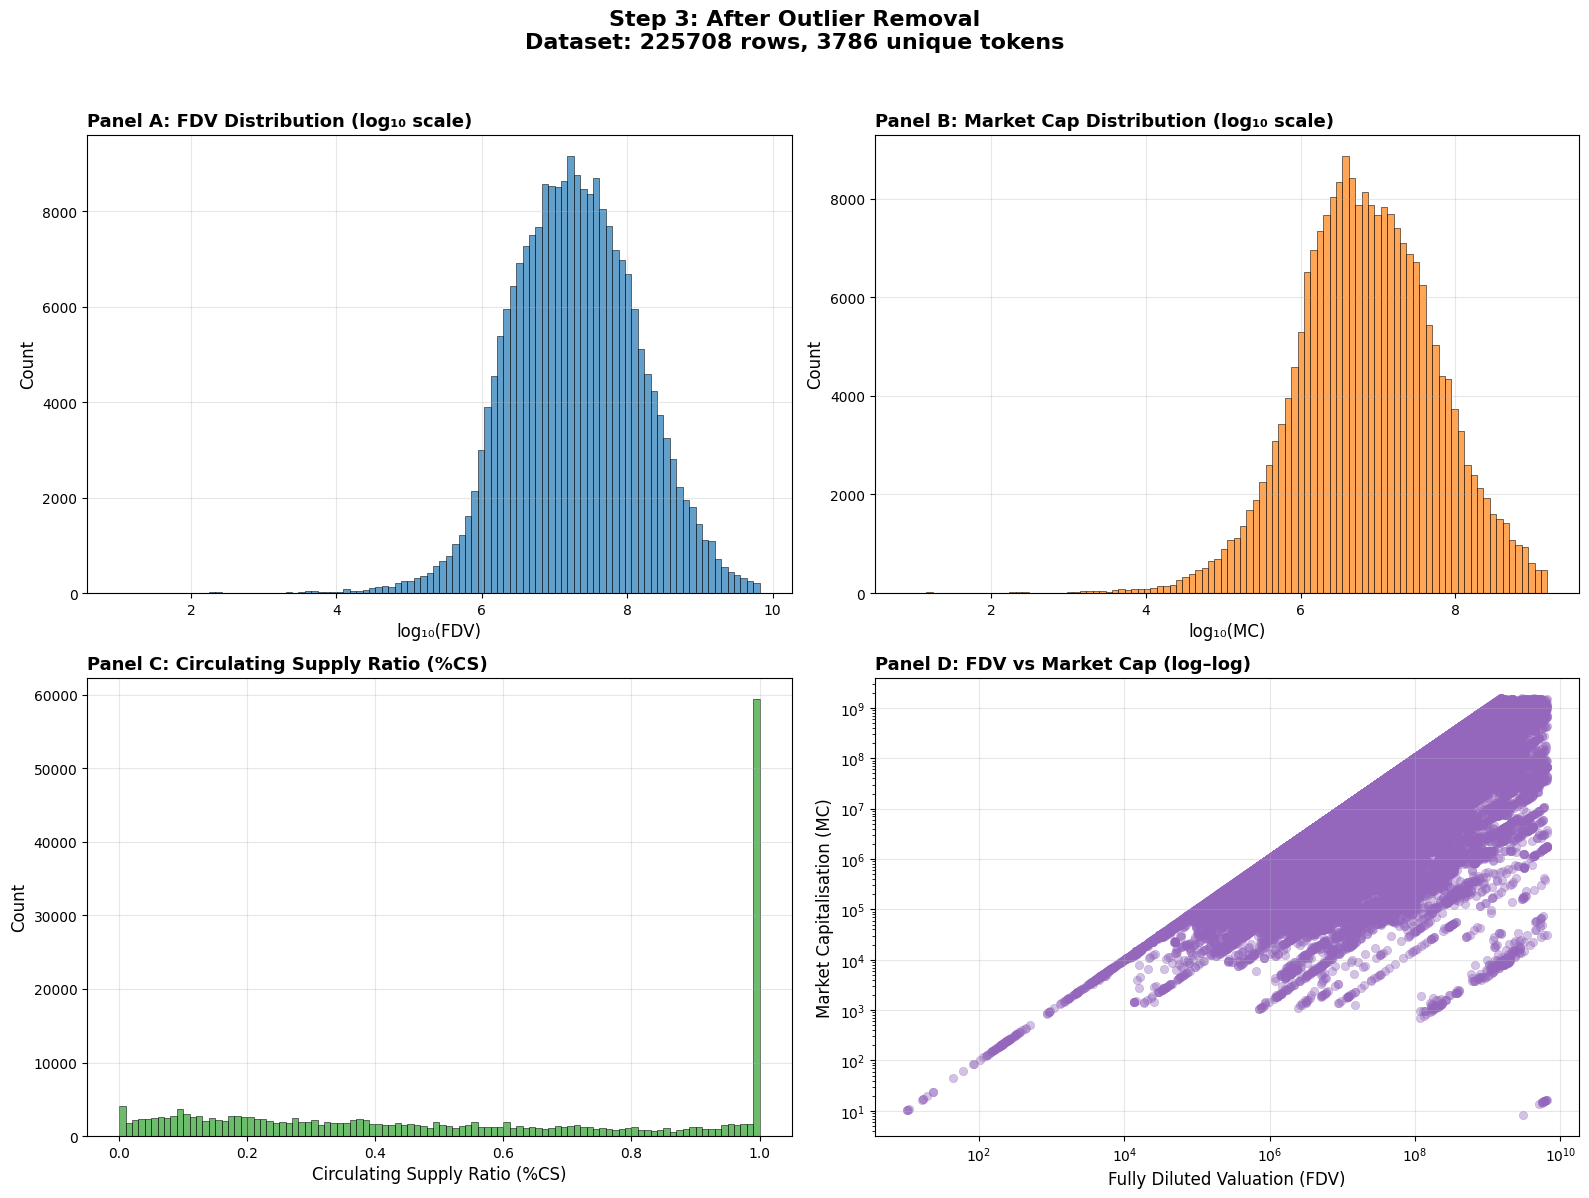

📊 Summary Statistics for After Outlier Removal:
   FDV: mean=1.22e+08, median=1.85e+07
   MC: mean=4.67e+07, median=6.89e+06
   %CS: mean=0.561, median=0.538
   %CS range: 0.000 - 1.000

CEHCK: Step 4: 221629 rows, 3744 unique tokens


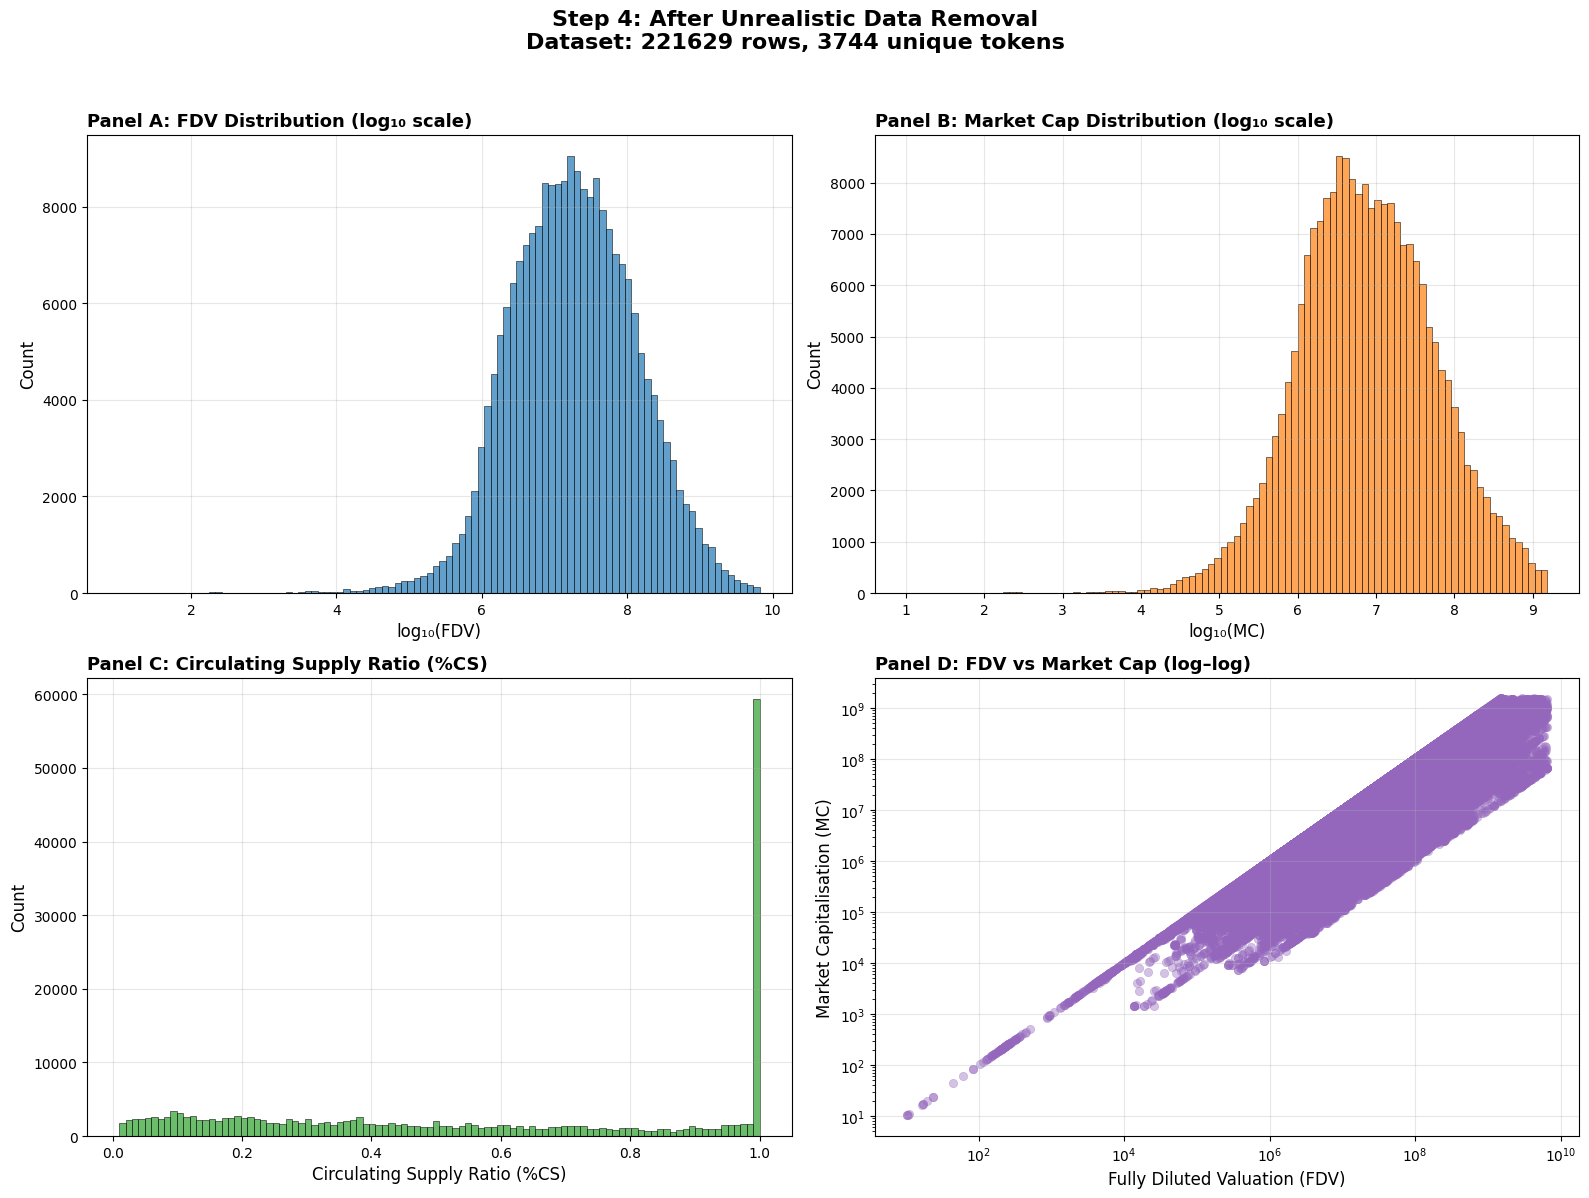

📊 Summary Statistics for After Unrealistic Data Removal:
   FDV: mean=1.11e+08, median=1.79e+07
   MC: mean=4.75e+07, median=7.17e+06
   %CS: mean=0.571, median=0.551
   %CS range: 0.010 - 1.000

CEHCK: Step 5: 221108 rows, 3500 unique tokens


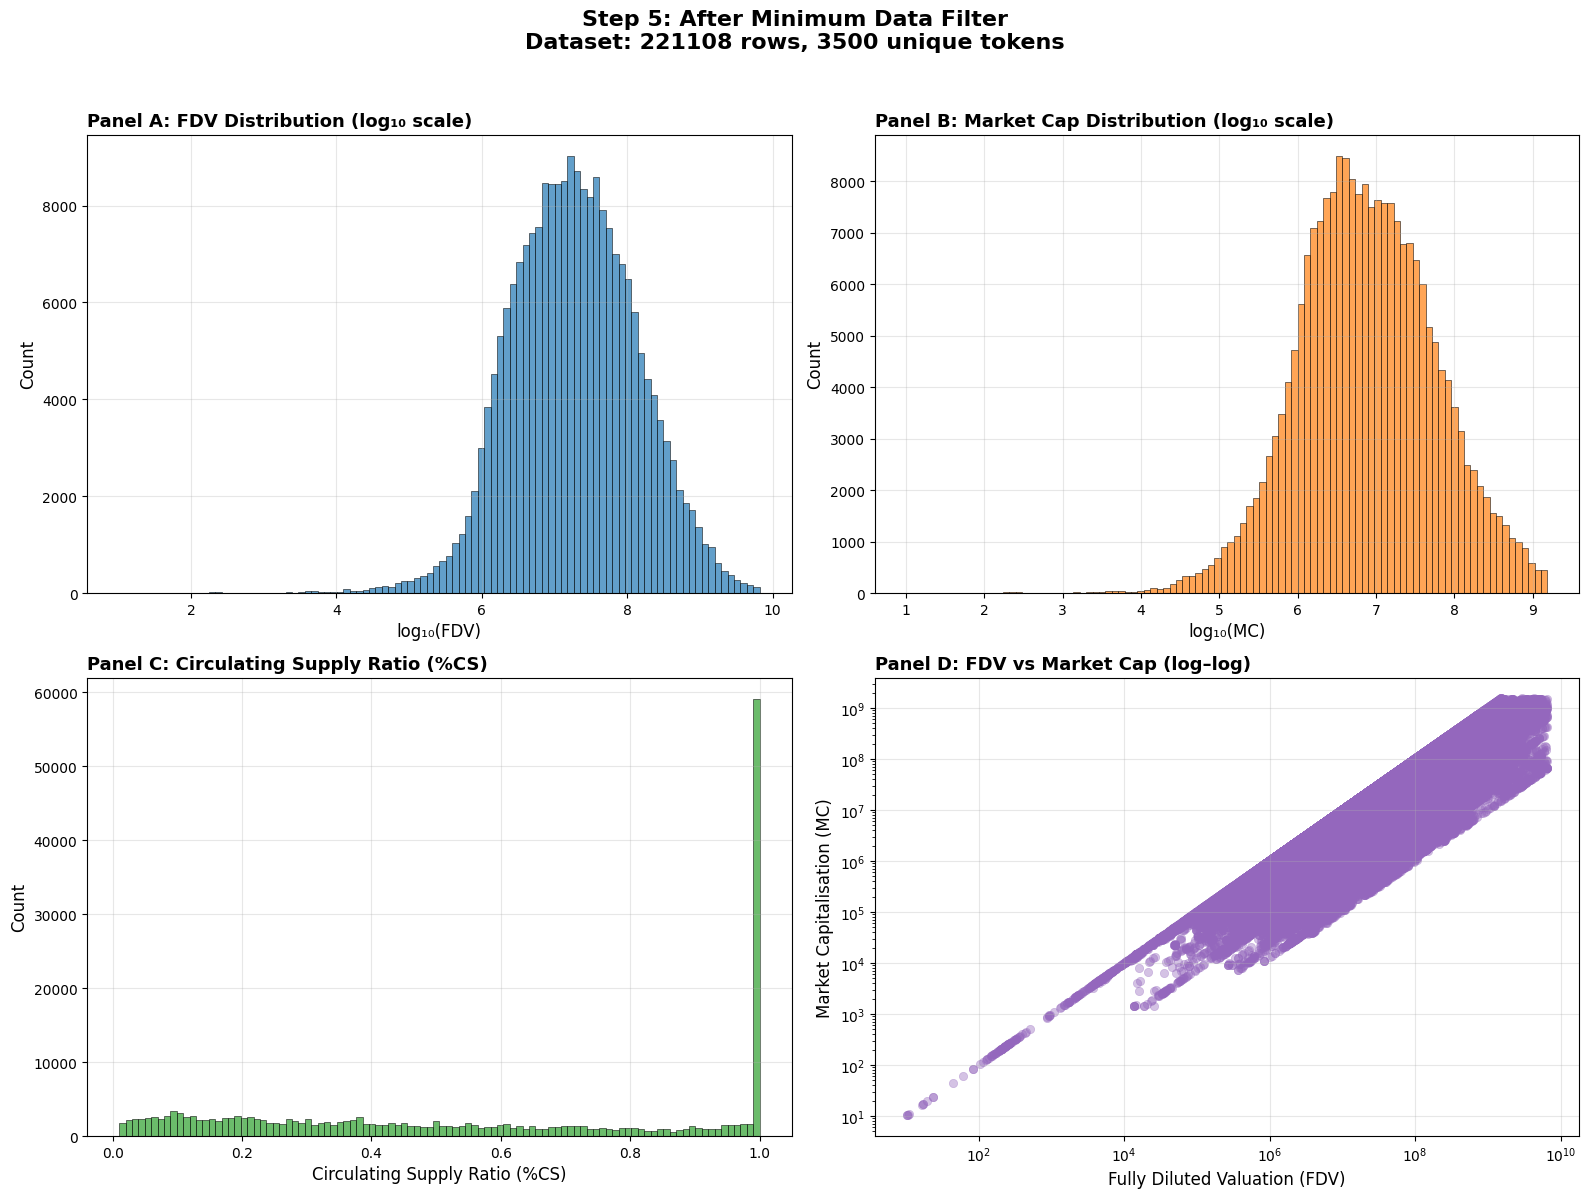

📊 Summary Statistics for After Minimum Data Filter:
   FDV: mean=1.11e+08, median=1.80e+07
   MC: mean=4.76e+07, median=7.19e+06
   %CS: mean=0.571, median=0.550
   %CS range: 0.010 - 1.000

CEHCK: Step 5: 178438 rows, 2812 unique tokens


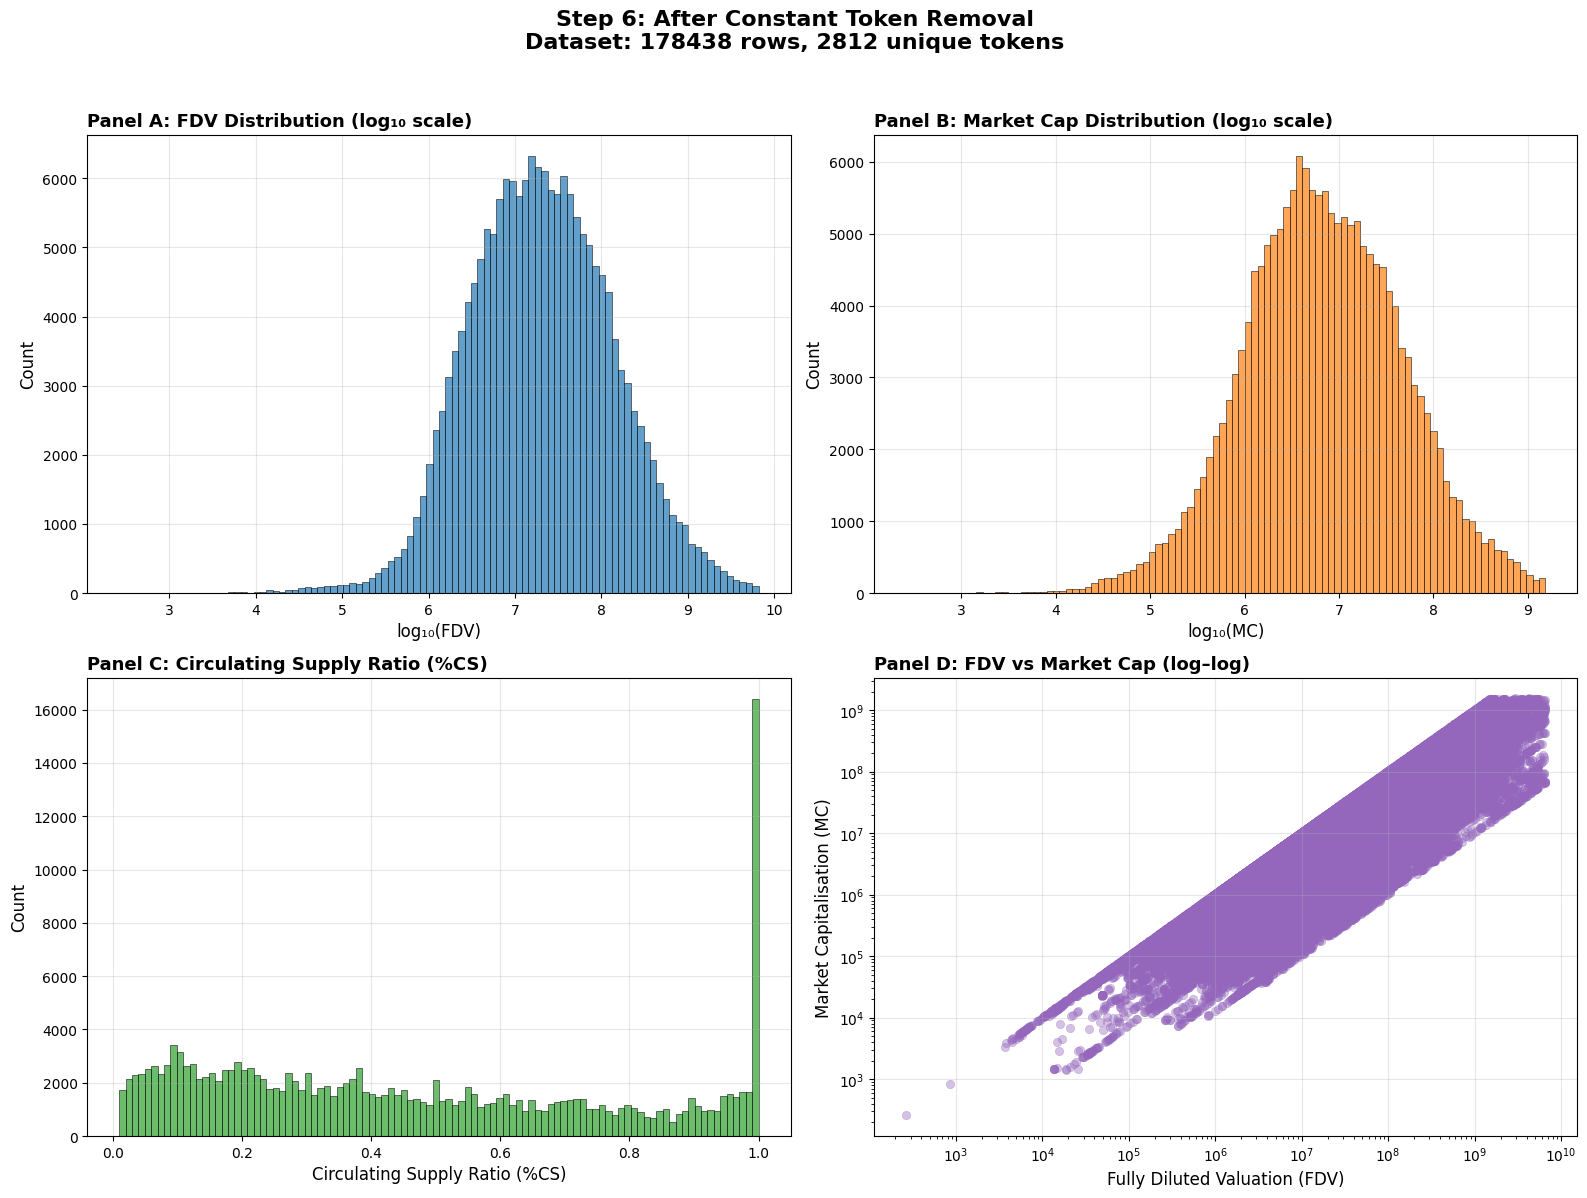

📊 Summary Statistics for After Constant Token Removal:
   FDV: mean=1.18e+08, median=1.95e+07
   MC: mean=3.89e+07, median=6.53e+06
   %CS: mean=0.469, median=0.408
   %CS range: 0.010 - 1.000

CEHCK: Step 6: 138377 rows, 1867 unique tokens


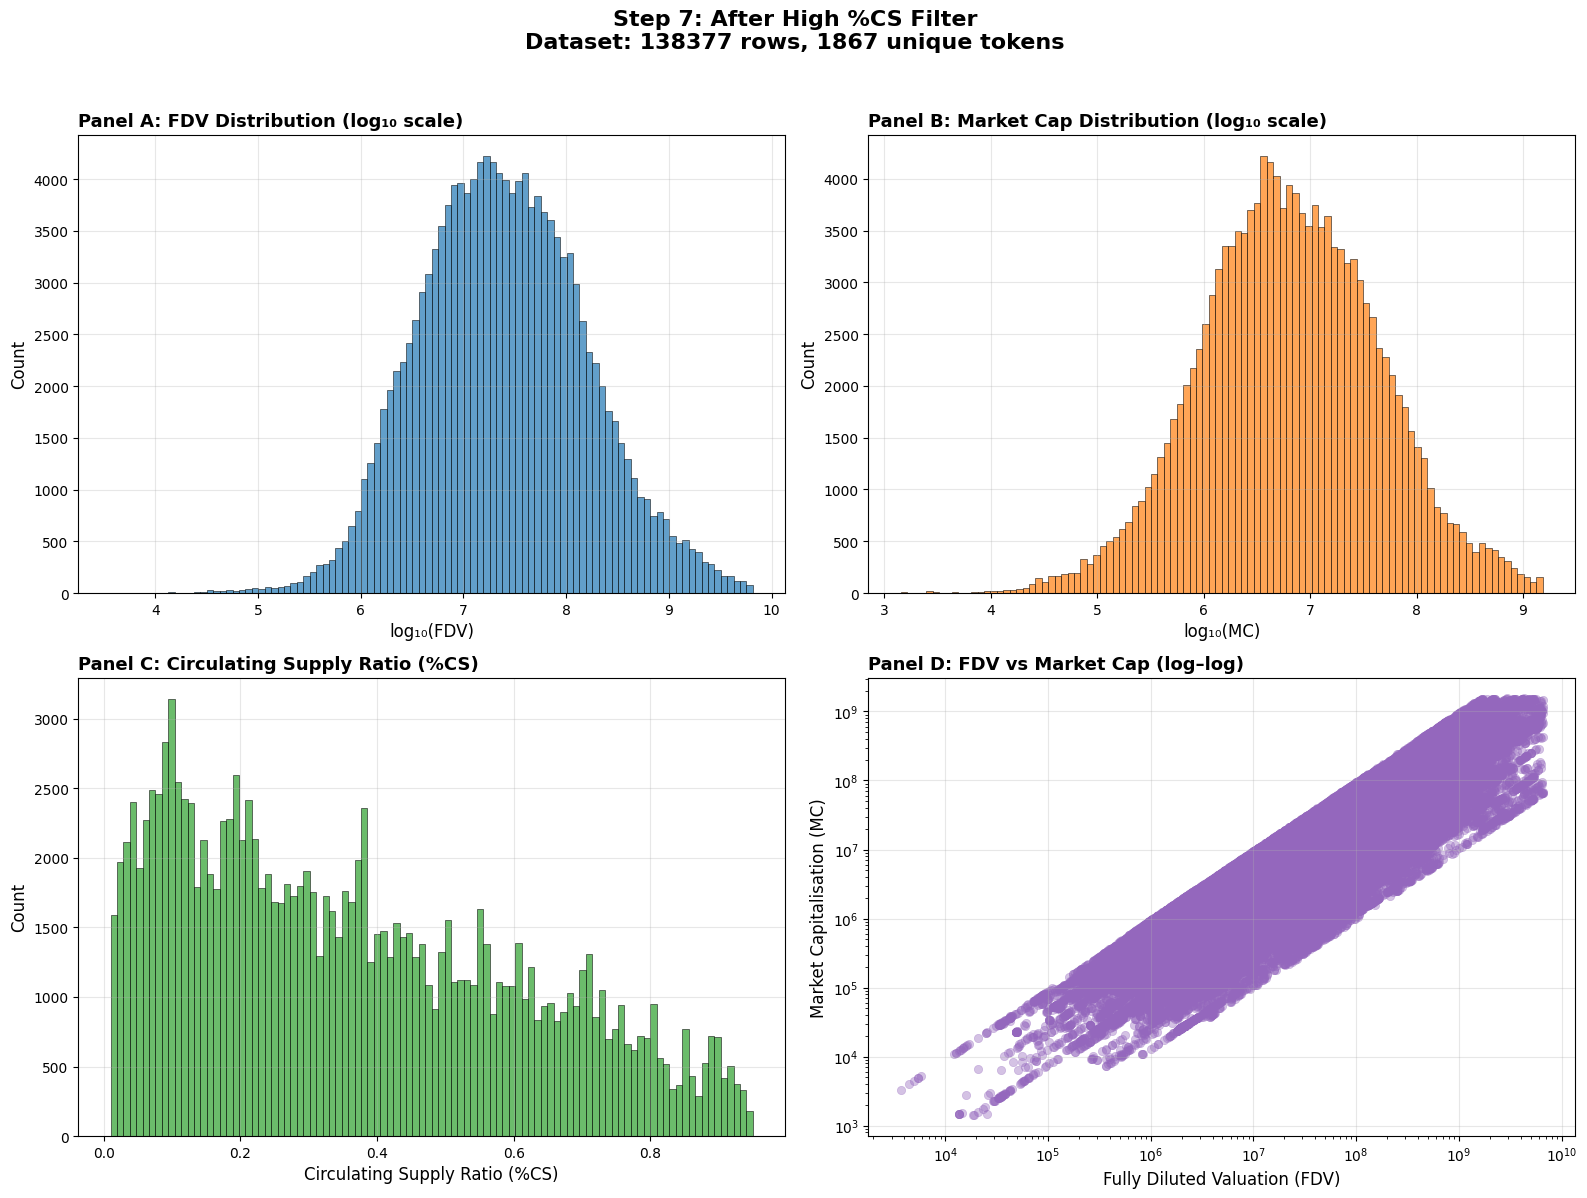

📊 Summary Statistics for After High %CS Filter:
   FDV: mean=1.35e+08, median=2.30e+07
   MC: mean=3.71e+07, median=6.20e+06
   %CS: mean=0.361, median=0.320
   %CS range: 0.010 - 0.950

CEHCK: Step 7: 114003 rows, 1598 unique tokens


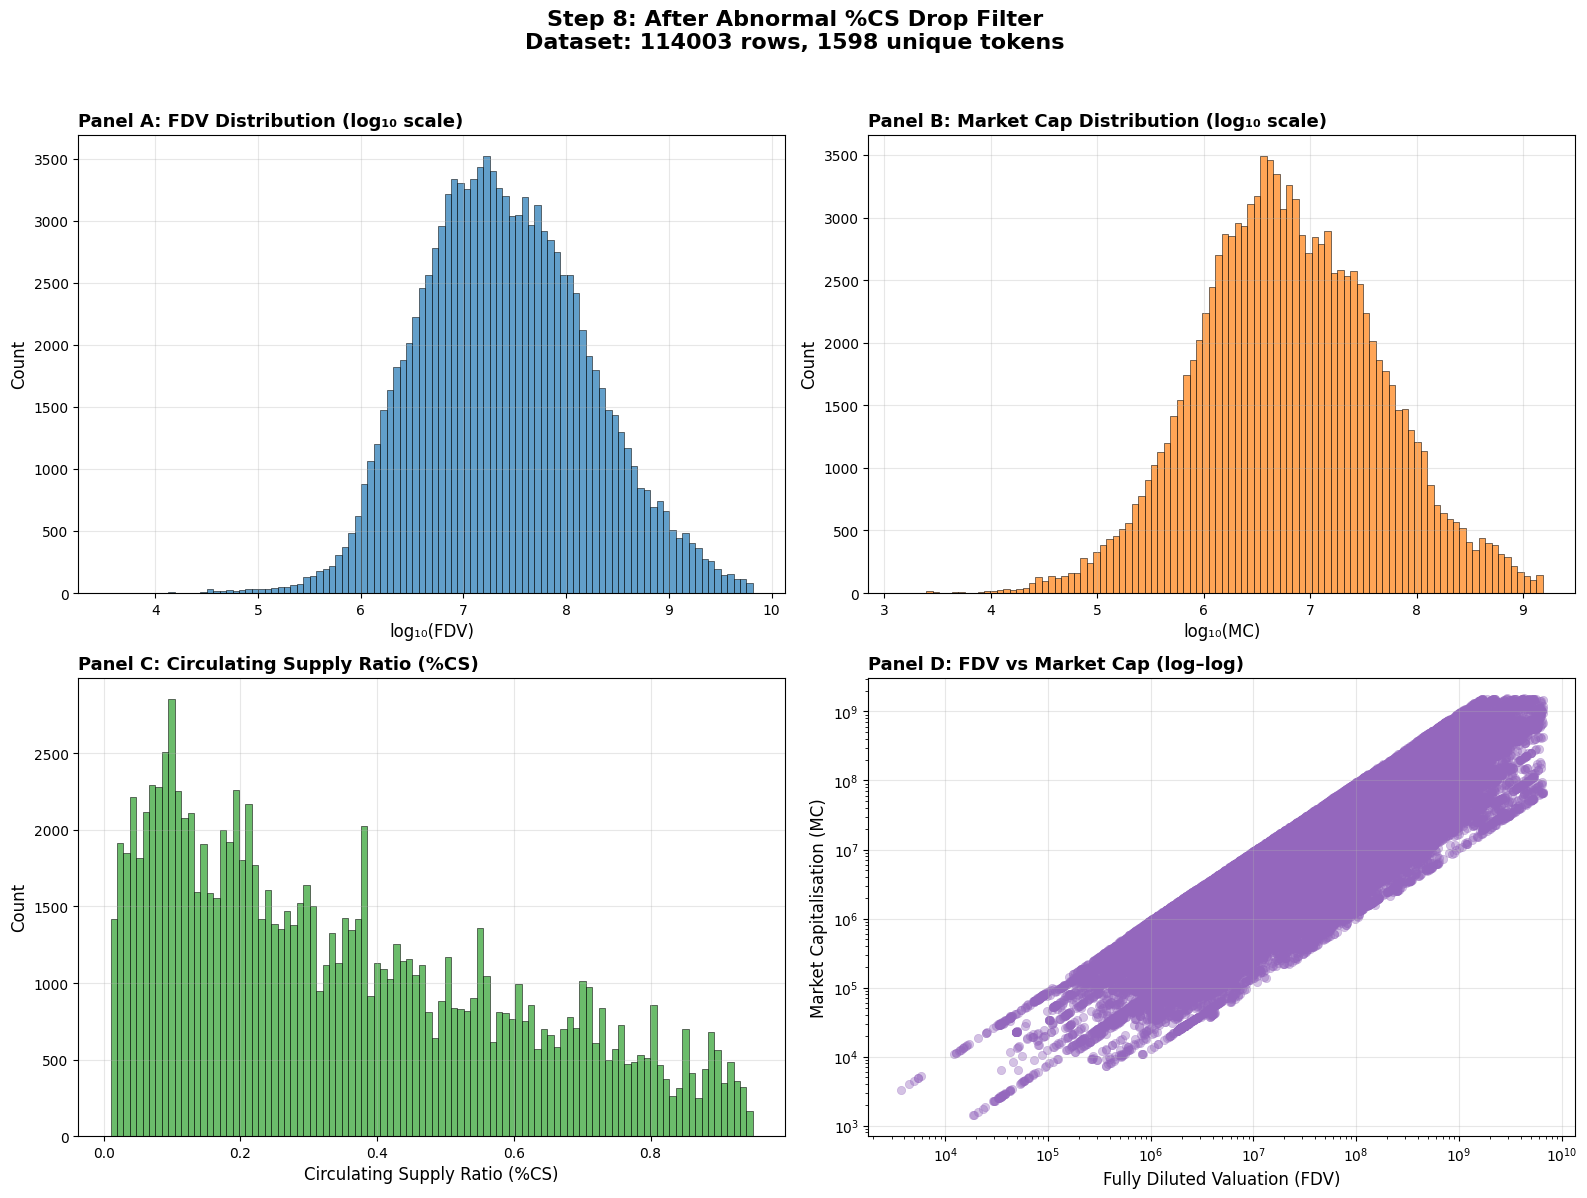

📊 Summary Statistics for After Abnormal %CS Drop Filter:
   FDV: mean=1.46e+08, median=2.27e+07
   MC: mean=3.87e+07, median=5.81e+06
   %CS: mean=0.349, median=0.296
   %CS range: 0.010 - 0.950

CEHCK: Step 8: 68770 rows, 874 unique tokens


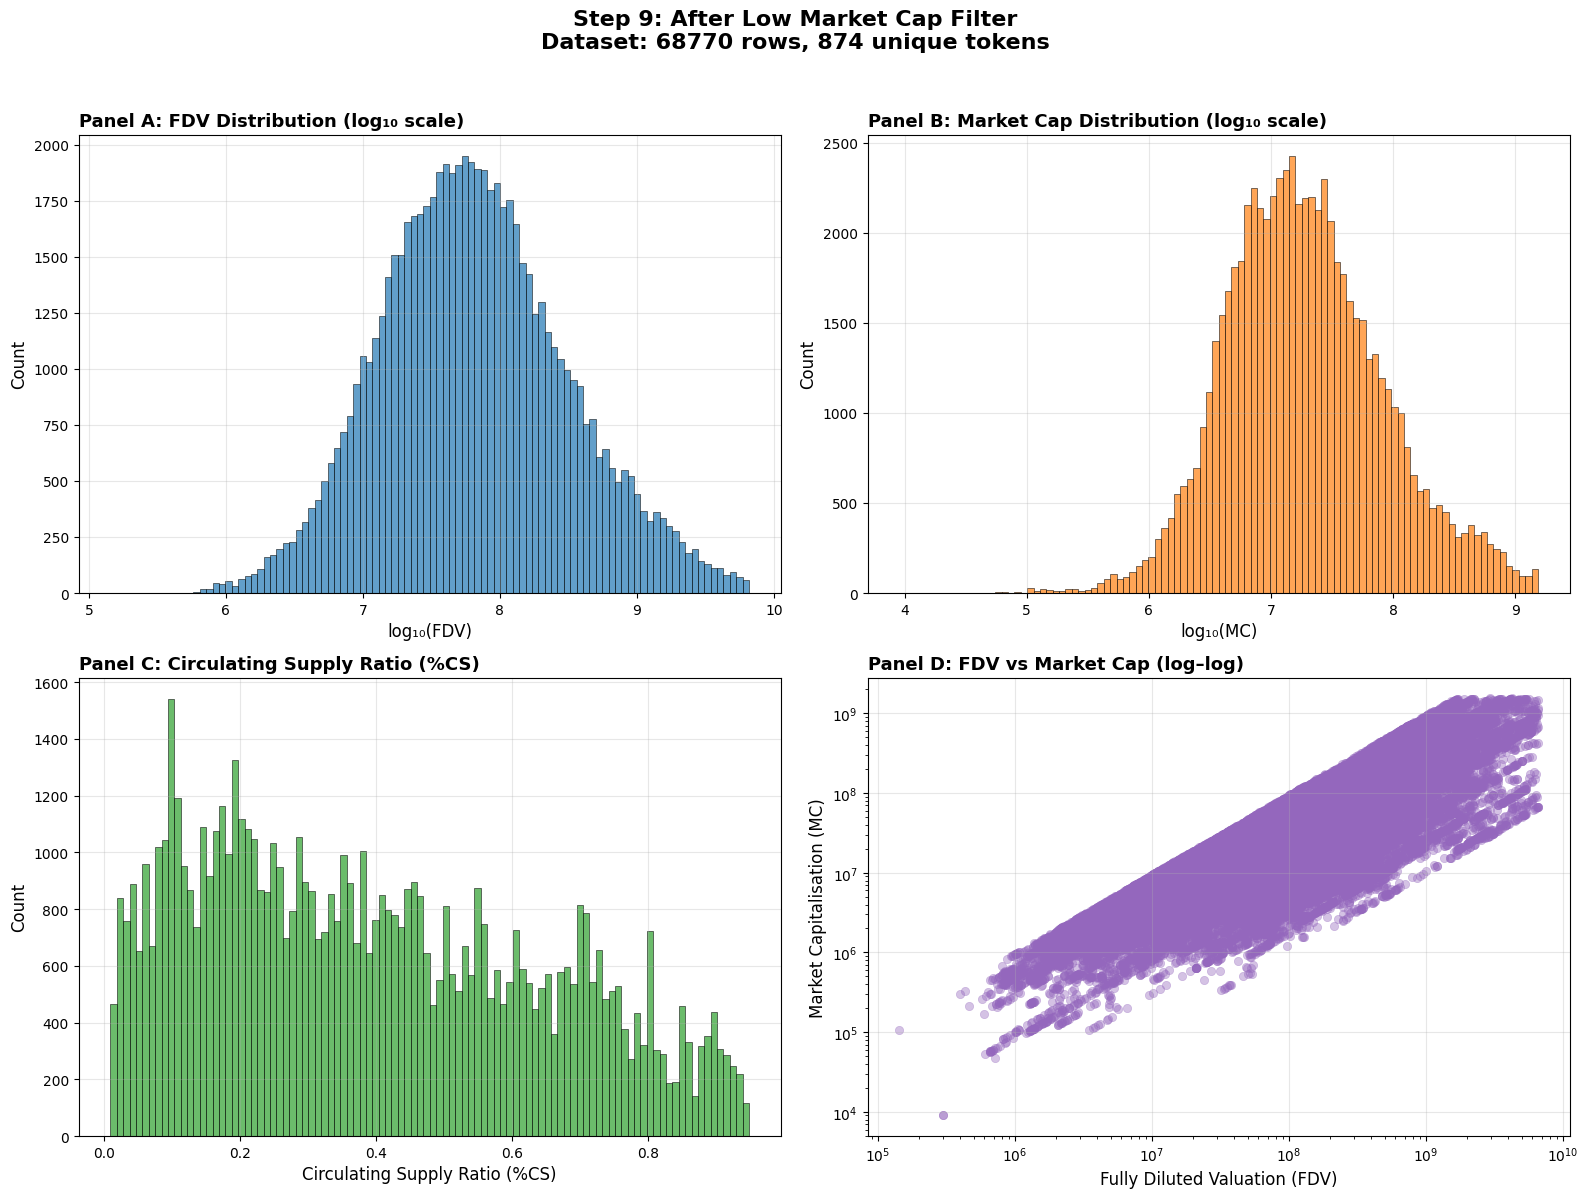

📊 Summary Statistics for After Low Market Cap Filter:
   FDV: mean=2.32e+08, median=5.98e+07
   MC: mean=6.27e+07, median=1.71e+07
   %CS: mean=0.391, median=0.357
   %CS range: 0.010 - 0.948

CEHCK: Step 9: 66253 rows, 826 unique tokens


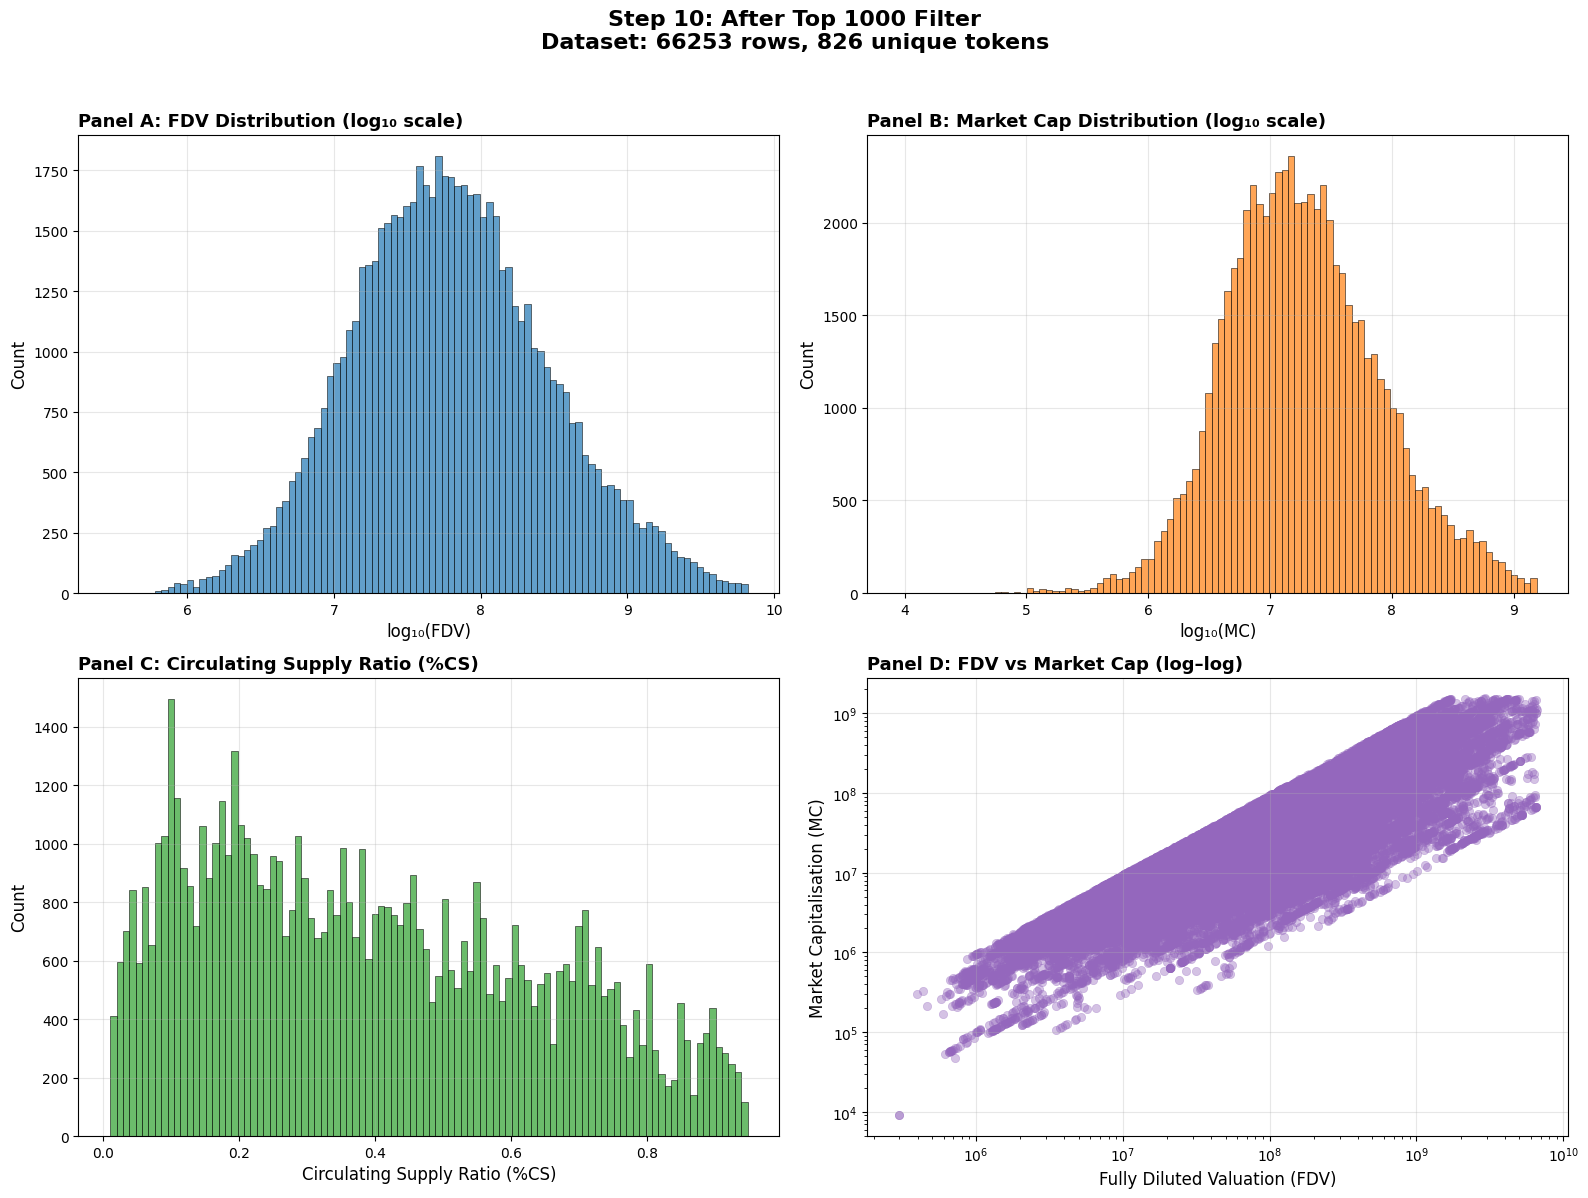

📊 Summary Statistics for After Top 1000 Filter:
   FDV: mean=2.10e+08, median=5.84e+07
   MC: mean=5.77e+07, median=1.69e+07
   %CS: mean=0.394, median=0.360
   %CS range: 0.010 - 0.948

✅ Final dataset: 66253 rows, 826 unique tokens


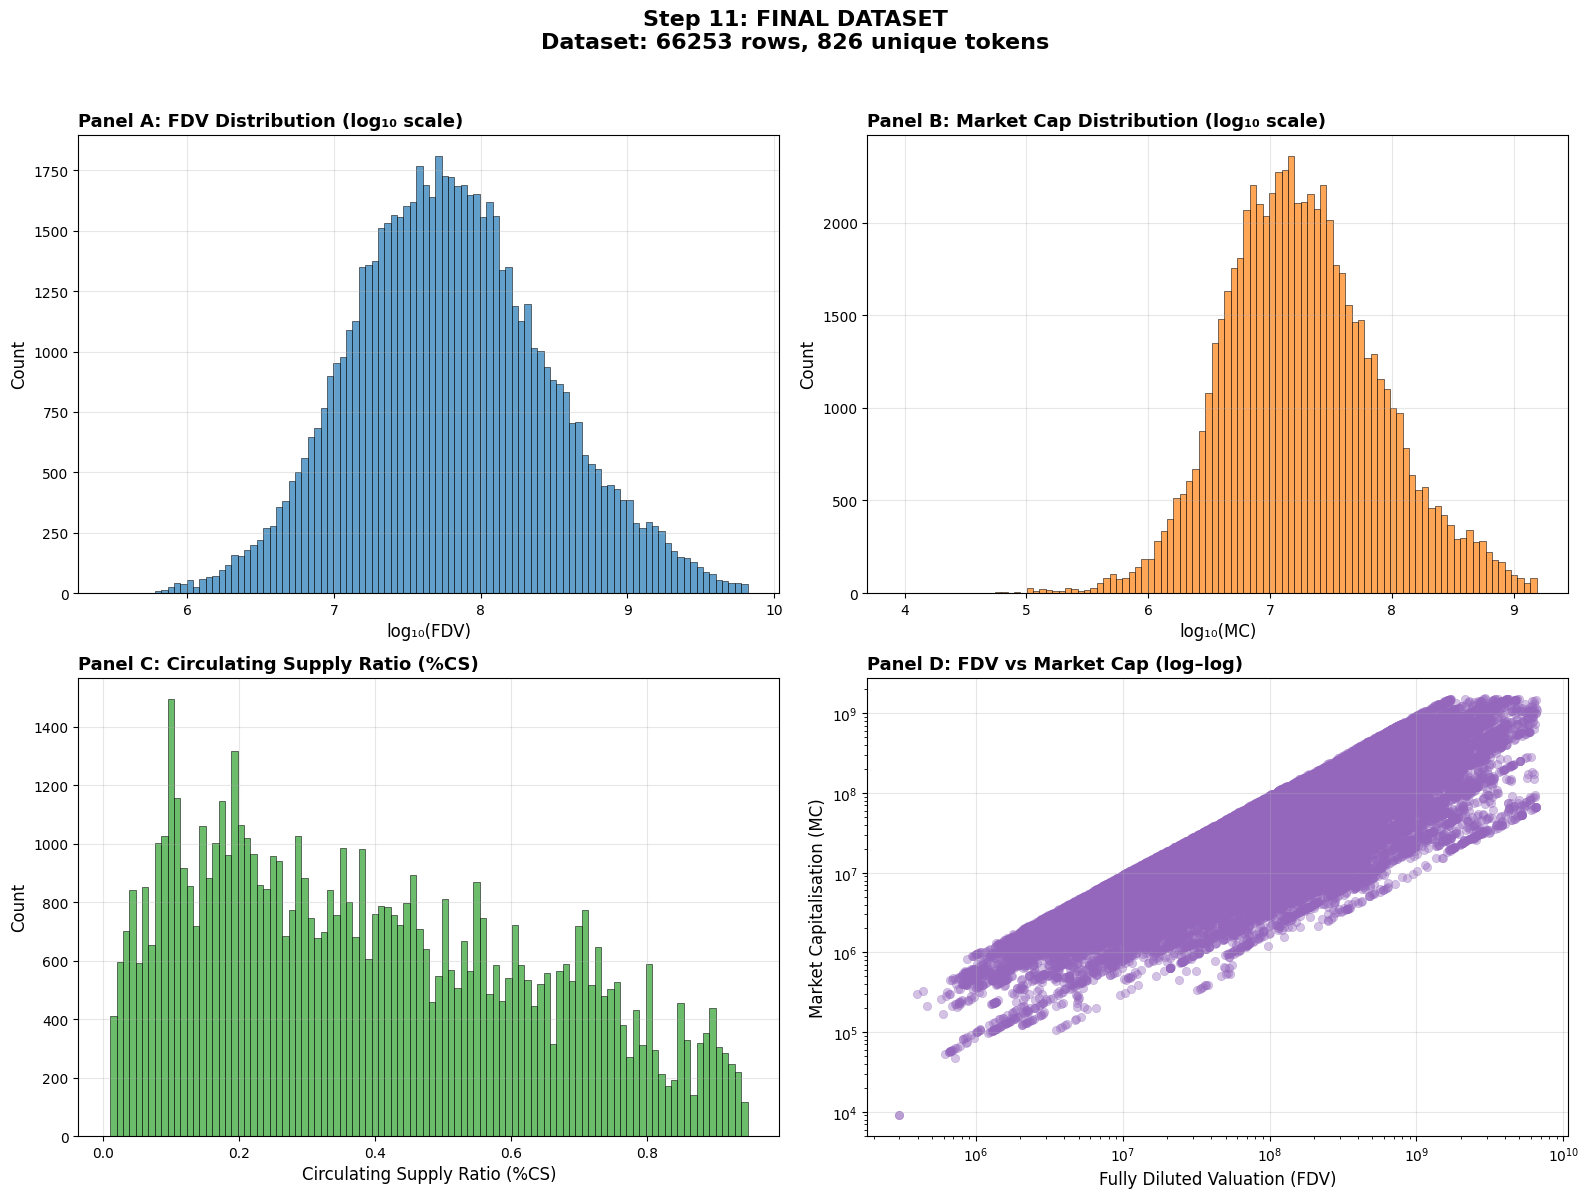

📊 Summary Statistics for FINAL DATASET:
   FDV: mean=2.10e+08, median=5.84e+07
   MC: mean=5.77e+07, median=1.69e+07
   %CS: mean=0.394, median=0.360
   %CS range: 0.010 - 0.948



In [25]:
# Now create dashboards at each filtering step
print("🔍 VISUALIZING DATA AT EACH FILTERING STEP")
print("=" * 60)
# ---------- PARAMETERS ----------
start_date = "2022-06-01"
end_date = "2025-06-01"
min_weeks_per_token = 5
min_avg_mc = 5_000_000  # Minimum average market cap per token

# ---------- STEP 1: PREPARE DATA ----------
df = fdv_df.copy()

# Rename columns
df.rename(columns={
    'token_name': 'symbol',
    'fdv': 'FDV',
    'market_cap': 'MC'
}, inplace=True)

# Parse dates
df['timestamp'] = pd.to_datetime(df['timestamp'])

# Compute circulating supply ratio
df['%CS'] = df['MC'] / df['FDV']

# Drop invalid rows (FDV=0, NaNs, inf, etc.)
df = df.replace([np.inf, -np.inf], np.nan)
df = df[df['FDV'] > 0]
df = df[df['MC'] > 0]
df = df[df['%CS'].notna() & (df['%CS'] > 0) & (df['%CS'] <= 1)]
print(f"CEHCK: Step 1: {df.shape[0]} rows, {df['symbol'].nunique()} unique tokens")
create_dashboard(df, "After Data Preparation", 1)

# ---------- STEP 2: FILTER BY DATE RANGE ----------
df = df[(df['timestamp'] >= start_date) & (df['timestamp'] <= end_date)].copy()
print(f"CEHCK: Step 2: {df.shape[0]} rows, {df['symbol'].nunique()} unique tokens")
create_dashboard(df, "After Date Range Filter", 2)

# ---------- STEP 3: REMOVE EXTREME OUTLIERS ----------
df = df[
    (df['FDV'] < df['FDV'].quantile(0.99)) &
    (df['MC'] < df['MC'].quantile(0.99))
].copy()
print(f"CEHCK: Step 3: {df.shape[0]} rows, {df['symbol'].nunique()} unique tokens")
create_dashboard(df, "After Outlier Removal", 3)

# ---------- STEP 3.5: REMOVE OBVIOUSLY BROKEN / UNREALISTIC DATA ----------
df = df[df['FDV'] < 1e12].copy()                               # FDV must be < $1T
df = df[df['FDV'] <= df['MC'] * 100]                   # FDV should not be 100x MC
df = df[~((df['FDV'] > 1e10) & (df['MC'] < 1e6))]    
print(f"CEHCK: Step 4: {df.shape[0]} rows, {df['symbol'].nunique()} unique tokens")
create_dashboard(df, "After Unrealistic Data Removal", 4)

# ---------- STEP 4: FILTER TOKENS WITH ENOUGH DATA ----------
token_counts = df['symbol'].value_counts()
valid_tokens = token_counts[token_counts >= min_weeks_per_token].index
df = df[df['symbol'].isin(valid_tokens)].copy()
print(f"CEHCK: Step 5: {df.shape[0]} rows, {df['symbol'].nunique()} unique tokens")
create_dashboard(df, "After Minimum Data Filter", 5)

# ---------- STEP 5: REMOVE CONSTANT OR BROKEN TOKENS ----------
fdv_std = df.groupby('symbol')['FDV'].std()
cs_std = df.groupby('symbol')['%CS'].std()
valid_tokens = fdv_std[(fdv_std > 0) & (cs_std > 0)].index
df = df[df['symbol'].isin(valid_tokens)].copy()
print(f"CEHCK: Step 5: {df.shape[0]} rows, {df['symbol'].nunique()} unique tokens")
create_dashboard(df, "After Constant Token Removal", 6)

# ---------- STEP 6.5: REMOVE TOKENS WITH >95% CIRCULATING SUPPLY ----------
cs_max = df.groupby('symbol')['%CS'].max()
valid_tokens = cs_max[cs_max < 0.95].index
df = df[df['symbol'].isin(valid_tokens)].copy()
print(f"CEHCK: Step 6: {df.shape[0]} rows, {df['symbol'].nunique()} unique tokens")
create_dashboard(df, "After High %CS Filter", 7)

# ---------- STEP 6.6: REMOVE TOKENS WITH NEGATIVE %CS JUMPS (>10%) ----------
df_sorted = df.sort_values(['symbol', 'timestamp']).copy()
df_sorted['cs_diff'] = df_sorted.groupby('symbol')['%CS'].diff()
tokens_with_cs_drops = df_sorted[df_sorted['cs_diff'] < -0.10]['symbol'].unique()

df = df[~df['symbol'].isin(tokens_with_cs_drops)].copy()
print(f"CEHCK: Step 7: {df.shape[0]} rows, {df['symbol'].nunique()} unique tokens")
create_dashboard(df, "After Abnormal %CS Drop Filter", 8)

# ---------- STEP 7: REMOVE VERY LOW CAP TOKENS ----------
avg_mc = df.groupby('symbol')['MC'].mean()
valid_tokens = avg_mc[avg_mc >= min_avg_mc].index
df = df[df['symbol'].isin(valid_tokens)].copy()
print(f"CEHCK: Step 8: {df.shape[0]} rows, {df['symbol'].nunique()} unique tokens")
create_dashboard(df, "After Low Market Cap Filter", 9)

# ---------- STEP 8: KEEP ONLY TOP 1000 BY LATEST FDV ----------
latest_date = df['timestamp'].max()
top_500_tokens = (
    df[df['timestamp'] == latest_date]
    .groupby("symbol")["FDV"]
    .mean()
    .sort_values(ascending=False)
    .head(1000)
    .index
)
df = df[df['symbol'].isin(top_500_tokens)].copy()
print(f"CEHCK: Step 9: {df.shape[0]} rows, {df['symbol'].nunique()} unique tokens")
create_dashboard(df, "After Top 1000 Filter", 10)

# ---------- STEP 9: COMPUTE TGE DATE + DAYS FROM TGE ----------
df['TGE_date'] = df.groupby('symbol')['timestamp'].transform('min')
df['day_from_TGE'] = (df['timestamp'] - df['TGE_date']).dt.days
df.drop(columns=['TGE_date'], inplace=True)

# ---------- STEP 10: CLEANUP ----------
df = df.drop_duplicates(subset=['timestamp', 'symbol']).sort_values(['symbol', 'timestamp'])
df = df.reset_index(drop=True)
df = df[['timestamp', 'symbol', 'day_from_TGE', '%CS', 'MC', 'FDV']]

print(f"✅ Final dataset: {df.shape[0]} rows, {df['symbol'].nunique()} unique tokens")
create_dashboard(df, "FINAL DATASET", 11)
